# Installation of modules.

In [3]:
!python -m pip install ../../CLAUDE
# !python -m pip install ../../RandomNumberManager
# !python -m pip install matplotlib
# !python -m pip install plotly
# !python -m pip install nbformat

Processing /Users/syahrizailm/Codes/lab/CLAUDE
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for claude: filename=claude-0.3-py3-none-any.whl size=17494 sha256=31af5ae5caa1985fa650aba568da19be28b3caa386f2745c85a8d287b29a57cc
  Stored in directory: /private/var/folders/5q/z8g_pbg51dxc9q44_yqyjj840000gn/T/pip-ephem-wheel-cache-gfs9q_mi/wheels/6a/d3/af/4b02e32dac59dfab231c0cec7f54a1d1e1a47fb39e91cc5637
Successfully built claude
  Attempting uninstall: claude
    Found existing installation: claude 0.3
    Uninstalling claude-0.3:
      Successfully uninstalled claude-0.3

[notice] A new release of pip available: 22.3.1 -> 24.2
[notice] To update, run: pip install --upgrade pip


# Sample code.

In [4]:
import claude
import numpy as np
import pandas as pd

da = claude.CLAUDE(nDescriptor = 1, \
                   nTarget = 2, \
                   degreePolynomialDescriptor = np.array([[0],[1],[2],[3]]), \
                   degreeActiveDescriptor = [[[0],[0,1]]])
df = pd.read_csv('exampledata.csv', skipinitialspace=True)
xSample = df[['descriptor']].values
ySample = df[['target1','target2']].values
da.fit(xSample,ySample)
x = np.arange(0.0,1.0+1e-6,0.01)
y = da.predict(x)

FileNotFoundError: [Errno 2] No such file or directory: 'exampledata.csv'

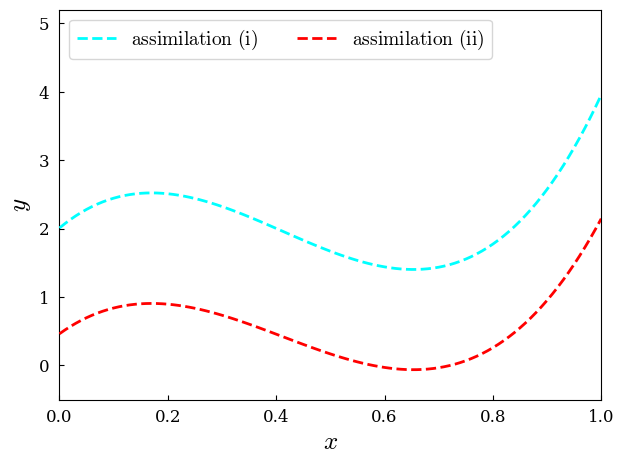

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib import rc
fs = 12
fs_label = 18
fs_legend = 14
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['mathtext.default'] = 'it'
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['font.size'] = fs
colorPred1 = 'cyan'
colorPred2 = 'red'
ppred1, = plt.plot(x,y[:,0], linewidth=2, linestyle='dashed', color=colorPred1, \
                   marker='None', markersize=0, markeredgewidth=0, markeredgecolor=colorPred1, markerfacecolor='None', clip_on=True, zorder=5, \
                   label=r'$\mathrm{assimilation} \ (\mathrm{i})$')
ppred2, = plt.plot(x,y[:,1], linewidth=2, linestyle='dashed', color=colorPred2, \
                   marker='None', markersize=0, markeredgewidth=0, markeredgecolor=colorPred2, markerfacecolor='None', clip_on=True, zorder=6, \
                   label=r'$\mathrm{assimilation} \ (\mathrm{ii})$')
plt.legend([ppred1,            ppred2], \
           [ppred1.get_label(),ppred2.get_label()], \
           prop={'size':fs_legend}, numpoints=1, loc='upper left', ncol=2)
plt.xlabel(r'$x$', fontsize=fs_label)
plt.ylabel(r'$y$', fontsize=fs_label)
plt.xticks(np.arange(0.0,1.0+1e-6,0.2), y=-0.01)
plt.yticks(np.arange(0.0,5.0+1e-6,1.0), x=-0.01)
plt.xlim(0.0,1.0)
plt.ylim(-0.5,5.2)
plt.tight_layout()
plt.show()
## initialization.
plt.figure()

# Import modules.

In [15]:
import claude
import rnmanager

ModuleNotFoundError: No module named 'rnmanager'

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib import rc
import pandas as pd
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['mathtext.default'] = 'it'
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
import plotly.graph_objects as go
import copy

# XML format initialization.

## Test 00: regression.

In [5]:
def truemodel_target1(xt):
    return 2.0 - xt + 5.0*(xt-0.7)**2 + 20.0*(xt-0.5)**3
def truemodel_target2(xt):
    return truemodel_target1(xt) - 1.5

In [6]:
da = claude.CLAUDE()

print('load model parameters.')
da.loadModelParameterFromFile()

print('load covariance matrix components.')
da.loadCovarianceMatrixFromFile()

print('read data for covariance matrix.')
datatable = pd.read_csv('exampledata.txt',comment='#',delimiter='\s+',na_values='----').values
for i in range(datatable.shape[0]):
    x = datatable[i,0]
    y1 = datatable[i,1]
    y2 = datatable[i,2]
    da.updateCovarianceMatrix([x],[y1,y2])

print('find precision matrix for maximum posterior probability.')
da.findMaximumPosteriorProbability()

print('parameters of linear regression model.')
param = da.calculateLinearRegressionParameter()

print('save model parameters.')
da.saveModelParameterToFile('parameter_model_output.xml')
print('save covariance matrix components.')
da.saveCovarianceMatrixToFile('covariance_matrix_output.xml')

load model parameters.
loadModelParameterFromFile: read header of model parameters.
loadModelParameterFromFile: read NumberDescriptor.
loadModelParameterFromFile: read DegreePolynomialDescriptor.
loadModelParameterFromFile: read Domain of descriptor.
loadModelParameterFromFile: read NumberTarget.
loadModelParameterFromFile: read DegreePolynomialTarget.
loadModelParameterFromFile: read ActiveVariable.
loadModelParameterFromFile: read InactiveVariable.
load covariance matrix components.
loadCovarianceMatrixFromFile: read covariance matrix from the file: covariance_matrix.xml
read data for covariance matrix.
find precision matrix for maximum posterior probability.
Warning in findMaximumPosteriorProbability: maximization for posterior probability is not converged.
parameters of linear regression model.
save model parameters.
save covariance matrix components.


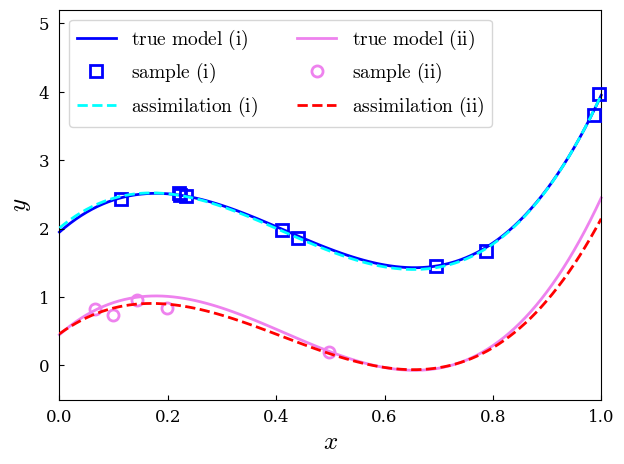

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [6]:
filenameinput1 = 'exampledata.txt'
# filenameoutput = 'predictcurve.pdf'
fs = 12
fs_label = 18
fs_legend = 14
plt.rcParams['font.size'] = fs
data1 = pd.read_csv(filenameinput1,comment='#',delimiter='\s+',na_values='----').values
xsample = data1[:,0]
ysample1 = data1[:,1]
ysample2 = data1[:,2]
nSample = len(xsample)
xtrue1 = np.arange(0.0,1.0+1e-6,0.01)
ytrue1 = truemodel_target1(xtrue1)
xtrue2 = np.arange(0.0,1.0+1e-6,0.01)
ytrue2 = truemodel_target2(xtrue2)
xpred = np.arange(0.0,1.0+1e-6,0.01)
ypred = da.predict(xpred)
ypred1 = ypred[:,0]
ypred2 = ypred[:,1]
colorTrue1 = 'blue'
colorTrue2 = 'violet'
colorPred1 = 'cyan'
colorPred2 = 'red'
ptrue1, = plt.plot(xtrue1,ytrue1, linewidth=2, linestyle='solid', color=colorTrue1, \
                   marker='None', markersize=0, markeredgewidth=0, markeredgecolor=colorTrue1, markerfacecolor='None', clip_on=False, zorder=1, \
                   label=r'$\mathrm{true} \ \mathrm{model} \ (\mathrm{i})$')
ptrue2, = plt.plot(xtrue2,ytrue2, linewidth=2, linestyle='solid', color=colorTrue2, \
                   marker='None', markersize=0, markeredgewidth=0, markeredgecolor=colorTrue2, markerfacecolor='None', clip_on=False, zorder=2, \
                   label=r'$\mathrm{true} \ \mathrm{model} \ (\mathrm{ii})$')
psample1, = plt.plot(xsample,ysample1, linewidth=0, linestyle='solid', color=colorTrue1, \
                     marker='s', markersize=8, markeredgewidth=2, markeredgecolor=colorTrue1, markerfacecolor='None', clip_on=False, zorder=3, \
                     label=r'$\mathrm{sample} \ (\mathrm{i})$')
psample2, = plt.plot(xsample,ysample2, linewidth=0, linestyle='solid', color=colorTrue2, \
                     marker='o', markersize=8, markeredgewidth=2, markeredgecolor=colorTrue2, markerfacecolor='None', clip_on=False, zorder=4, \
                     label=r'$\mathrm{sample} \ (\mathrm{ii})$')
ppred1, = plt.plot(xpred,ypred1, linewidth=2, linestyle='dashed', color=colorPred1, \
                   marker='None', markersize=0, markeredgewidth=0, markeredgecolor=colorPred1, markerfacecolor='None', clip_on=True, zorder=5, \
                   label=r'$\mathrm{assimilation} \ (\mathrm{i})$')
ppred2, = plt.plot(xpred,ypred2, linewidth=2, linestyle='dashed', color=colorPred2, \
                   marker='None', markersize=0, markeredgewidth=0, markeredgecolor=colorPred2, markerfacecolor='None', clip_on=True, zorder=6, \
                   label=r'$\mathrm{assimilation} \ (\mathrm{ii})$')
plt.legend([ptrue1,            psample1,            ppred1,            ptrue2,            psample2,            ppred2], \
           [ptrue1.get_label(),psample1.get_label(),ppred1.get_label(),ptrue2.get_label(),psample2.get_label(),ppred2.get_label()], \
           prop={'size':fs_legend}, numpoints=1, loc='upper left', ncol=2)
plt.xlabel(r'$x$', fontsize=fs_label)
plt.ylabel(r'$y$', fontsize=fs_label)
plt.xticks(np.arange(0.0,1.0+1e-6,0.2), y=-0.01)
plt.yticks(np.arange(0.0,5.0+1e-6,1.0), x=-0.01)
plt.xlim(0.0,1.0)
plt.ylim(-0.5,5.2)
plt.tight_layout()
plt.show()
# plt.savefig(filenameoutput, transparent=True)
## initialization.
plt.figure()

## Test 01: statistics.

In [7]:
def truemodel_sparse_target1(xt):
    return 2.0 - xt + 5.0*(xt-0.7)**2 + 20.0*(xt-0.5)**3
def truemodel_sparse_target2(xt):
    return truemodel_sparse_target1(xt) - 1.5

In [8]:
da_sparse = claude.CLAUDE()

print('load model parameters.')
da_sparse.loadModelParameterFromFile()

print('load covariance matrix components.')
da_sparse.loadCovarianceMatrixFromFile()

print('read data for covariance matrix.')
datatable = pd.read_csv('exampledata_sparse.txt',comment='#',delimiter='\s+',na_values='----').values
for i in range(datatable.shape[0]):
    x = datatable[i,0]
    y1 = datatable[i,1]
    y2 = datatable[i,2]
    da_sparse.updateCovarianceMatrix([x],[y1,y2])

print('find precision matrix for maximum posterior probability.')
da_sparse.findMaximumPosteriorProbability()

print('parameters of linear regression model.')
param_sparse = da_sparse.calculateLinearRegressionParameter()

print('save model parameters.')
da_sparse.saveModelParameterToFile('parameter_model_sparse_output.xml')
print('save covariance matrix components.')
da_sparse.saveCovarianceMatrixToFile('covariance_matrix_sparse_output.xml')

load model parameters.
loadModelParameterFromFile: read header of model parameters.
loadModelParameterFromFile: read NumberDescriptor.
loadModelParameterFromFile: read DegreePolynomialDescriptor.
loadModelParameterFromFile: read Domain of descriptor.
loadModelParameterFromFile: read NumberTarget.
loadModelParameterFromFile: read DegreePolynomialTarget.
loadModelParameterFromFile: read ActiveVariable.
loadModelParameterFromFile: read InactiveVariable.
load covariance matrix components.
loadCovarianceMatrixFromFile: read covariance matrix from the file: covariance_matrix.xml
read data for covariance matrix.
find precision matrix for maximum posterior probability.
parameters of linear regression model.
save model parameters.
save covariance matrix components.


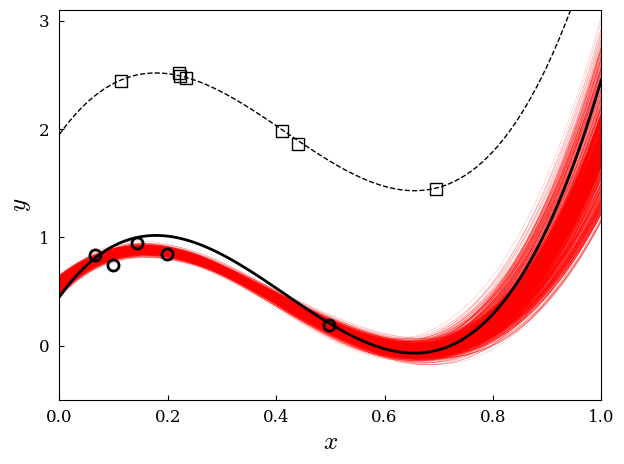

<Figure size 640x480 with 0 Axes>

In [9]:
filenameinput1 = 'exampledata_sparse.txt'
filenameModelParameter = 'parameter_model_sparse_output.xml'
filenameCovarianceMatrix = 'covariance_matrix_sparse_output.xml'
# filenameoutput = 'predictcurve_statistics_sparse.pdf'
fs = 12
fs_label = 18
fs_legend = 14
plt.rcParams['font.size'] = fs
rng = rnmanager.RandomNumberManager()
rng.restoreState()
color1 = 'red'
nStatistics = 1000
precisionMatrix = da_sparse.getPrecisionMatrixMax()
x1 = np.arange(0.0,1.0+1e-6,0.01)
y1 = np.zeros((x1.shape[0],2), dtype=float)
for iStatistics in range(nStatistics):
    da_sparse.transitionPrecisionMatrix(precisionMatrix)
    for i in range(x1.shape[0]):
        y1[i] = da_sparse.predict([x1[i]], precisionMatrix)
    p, = plt.plot(x1,y1[:,1], linewidth=0.1, linestyle='solid', color=color1, \
                marker='None', markersize=0, markeredgewidth=0, markeredgecolor=color1, markerfacecolor='None', clip_on=True, zorder=1, \
                label=r'$\mathrm{predict}$')
data1 = pd.read_csv(filenameinput1,comment='#',delimiter='\s+',na_values='----').values
xsample = data1[:,0]
ysample1 = data1[:,1]
ysample2 = data1[:,2]
xtrue = np.arange(0.0,1.0+1e-6,0.01)
ytrue1 = truemodel_sparse_target1(xtrue)
ytrue2 = truemodel_sparse_target2(xtrue)
color2 = 'black'
psample1, = plt.plot(xsample,ysample1, linewidth=0, linestyle='solid', color=color2, \
                     marker='s', markersize=8, markeredgewidth=1, markeredgecolor=color2, markerfacecolor='None', clip_on=True, zorder=4, \
                     label=r'$\mathrm{sample}$')
psample2, = plt.plot(xsample,ysample2, linewidth=0, linestyle='solid', color=color2, \
                     marker='o', markersize=8, markeredgewidth=2, markeredgecolor=color2, markerfacecolor='None', clip_on=True, zorder=4, \
                     label=r'$\mathrm{sample}$')
ptrue1, = plt.plot(xtrue,ytrue1, linewidth=1, linestyle='dashed', color=color2, \
                   marker='None', markersize=0, markeredgewidth=0, markeredgecolor=color2, markerfacecolor='None', clip_on=True, zorder=2, \
                   label=r'$\mathrm{true} \ \mathrm{model}$')
ptrue2, = plt.plot(xtrue,ytrue2, linewidth=2, linestyle='solid', color=color2, \
                   marker='None', markersize=0, markeredgewidth=0, markeredgecolor=color2, markerfacecolor='None', clip_on=True, zorder=2, \
                   label=r'$\mathrm{true} \ \mathrm{model}$')
# plt.legend([ptrue2,            psample2,            p], \
#            [ptrue2.get_label(),psample2.get_label(),p.get_label()], \
#            prop={'size':fs_legend}, numpoints=1, loc='upper left', ncol=1, framealpha=1.0)
plt.xlabel(r'$x$', fontsize=fs_label)
plt.ylabel(r'$y$', fontsize=fs_label)
plt.xticks(np.arange(0.0,1.0+1e-6,0.2), y=-0.01)
plt.yticks(np.arange(0.0,3.0+1e-6,1.0), x=-0.01)
plt.xlim(0.0,1.0)
plt.ylim(-0.5,3.1)
plt.tight_layout()
# plt.savefig(filenameoutput, transparent=True)
plt.show()
## initialization.
plt.figure()
rng.storeState()

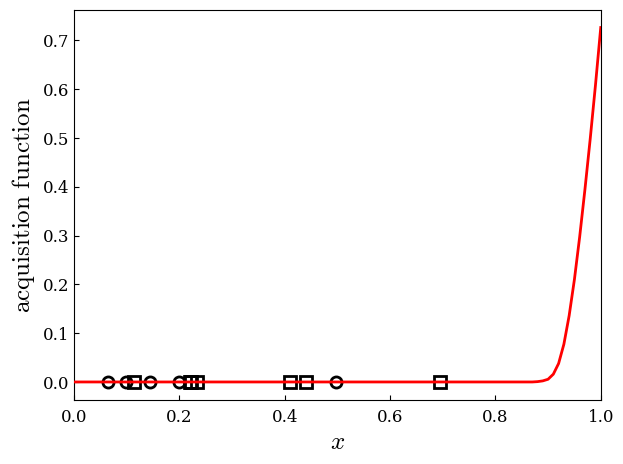

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [10]:
filenameinput1 = 'exampledata_sparse.txt'
# filenameoutput = 'acquisitionfunction_sparse.pdf'
fs = 12
fs_label = 18
fs_legend = 14
plt.rcParams['font.size'] = fs
data1 = pd.read_csv(filenameinput1,comment='#',delimiter='\s+',na_values='----').values
xsample = data1[:,0]
ysample1 = data1[:,1]-data1[:,1]
ysample2 = data1[:,2]-data1[:,2]
nSample = len(xsample)
xacqui = np.arange(0.0,1.0+1e-6,0.01)
yacqui = da_sparse.acquisitionFunction(xacqui.reshape(-1,1))
yacquiSD = yacqui[:,0]
yacquiEI = yacqui[:,1]
color0 = 'black'
color1 = 'red'
color2 = 'blue'
psample1, = plt.plot(xsample,ysample1, linewidth=0, linestyle='solid', color=color0, \
                     marker='s', markersize=8, markeredgewidth=2, markeredgecolor=color0, markerfacecolor='None', clip_on=False, zorder=3, \
                     label=r'$\mathrm{sample} \ (\mathrm{i})$')
psample2, = plt.plot(xsample,ysample2, linewidth=0, linestyle='solid', color=color0, \
                     marker='o', markersize=8, markeredgewidth=2, markeredgecolor=color0, markerfacecolor='None', clip_on=False, zorder=4, \
                     label=r'$\mathrm{sample} \ (\mathrm{ii})$')
pacquiEI, = plt.plot(xacqui,yacquiEI, linewidth=2, linestyle='solid', color=color1, \
                   marker='None', markersize=0, markeredgewidth=0, markeredgecolor=color1, markerfacecolor='None', clip_on=True, zorder=5, \
                   label=r'$\mathrm{acquisition} \ (\mathrm{function})$')
# pacquiSD, = plt.plot(xacqui,yacquiSD, linewidth=2, linestyle='solid', color=color2, \
#                    marker='None', markersize=0, markeredgewidth=0, markeredgecolor=color1, markerfacecolor='None', clip_on=True, zorder=5, \
#                    label=r'$\mathrm{acquisition} \ (\mathrm{function})$')
plt.xlabel(r'$x$', fontsize=fs_label)
plt.ylabel(r'$\mathrm{acquisition} \ \mathrm{function}$', fontsize=fs_label)
plt.xticks(np.arange(0.0,1.0+1e-6,0.2), y=-0.01)
# plt.yticks(np.arange(0.0,5.0+1e-6,1.0), x=-0.01)
plt.xlim(0.0,1.0)
# plt.ylim(-0.5,5.2)
plt.tight_layout()
# plt.savefig(filenameoutput, transparent=True)
plt.show()
## initialization.
plt.figure()

## Test 02: sine curve.

### true models.

In [11]:
def truemodel_sine_target1(xt):
    return 2.0 + 0.2*np.sin(2*np.pi*xt) + 0.3*np.sin(2*np.pi*2*xt) - 0.2*np.sin(2*np.pi*3*xt) + 0.1*np.sin(2*np.pi*4*xt) - 0.3*np.sin(2*np.pi*5*xt) + 0.2*np.sin(2*np.pi*6*xt)
def truemodel_sine_target2(xt):
    return truemodel_sine_target1(xt) - 2.0 - 0.6*np.sin(2*np.pi*xt)

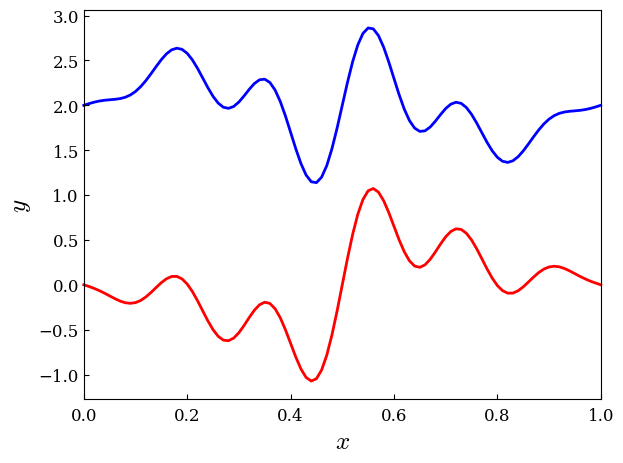

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [12]:
# filenameoutput = 'truecurve_sine.pdf'
fs = 12
fs_label = 18
fs_legend = 14
plt.rcParams['font.size'] = fs
xtrue1 = np.arange(0.0,1.0+1e-6,0.01)
xtrue2 = xtrue1
ytrue1 = truemodel_sine_target1(xtrue1)
ytrue2 = truemodel_sine_target2(xtrue2)
colorTrue1 = 'blue'
colorTrue2 = 'red'
ptrue1, = plt.plot(xtrue1,ytrue1, linewidth=2, linestyle='solid', color=colorTrue1, \
                   marker='None', markersize=0, markeredgewidth=0, markeredgecolor=colorTrue1, markerfacecolor='None', clip_on=False, zorder=1, \
                   label=r'$\mathrm{true} \ \mathrm{model} \ (\mathrm{i})$')
ptrue2, = plt.plot(xtrue2,ytrue2, linewidth=2, linestyle='solid', color=colorTrue2, \
                   marker='None', markersize=0, markeredgewidth=0, markeredgecolor=colorTrue2, markerfacecolor='None', clip_on=False, zorder=2, \
                   label=r'$\mathrm{true} \ \mathrm{model} \ (\mathrm{ii})$')
plt.xlabel(r'$x$', fontsize=fs_label)
plt.ylabel(r'$y$', fontsize=fs_label)
plt.xticks(np.arange(0.0,1.0+1e-6,0.2), y=-0.01)
# plt.yticks(np.arange(0.0,5.0+1e-6,1.0), x=-0.01)
plt.xlim(0.0,1.0)
# plt.ylim(-0.5,5.2)
plt.tight_layout()
plt.show()
# plt.savefig(filenameoutput, transparent=True)
## initialization.
plt.figure()

### Random sampling.

loadModelParameterFromFile: read header of model parameters.
loadModelParameterFromFile: read NumberDescriptor.
loadModelParameterFromFile: read DegreePolynomialDescriptor.
loadModelParameterFromFile: read Domain of descriptor.
loadModelParameterFromFile: read NumberTarget.
loadModelParameterFromFile: read DegreePolynomialTarget.
loadModelParameterFromFile: read ActiveVariable.
loadModelParameterFromFile: read InactiveVariable.
loadCovarianceMatrixFromFile: read covariance matrix from the file: covariance_matrix_sine.xml
iSample = 0
iSample = 1
iSample = 2
iSample = 3
iSample = 4
iSample = 5


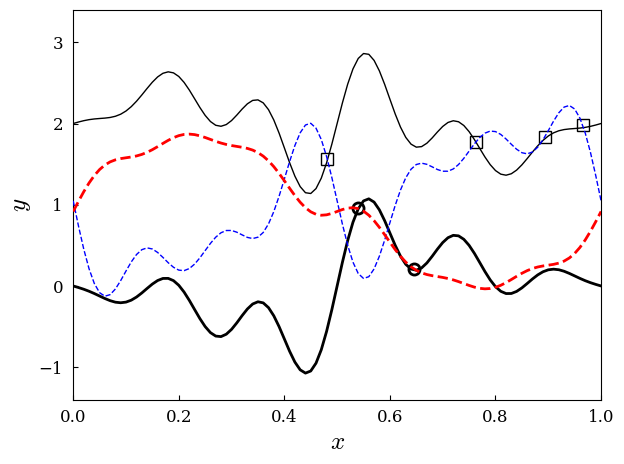

iSample = 6


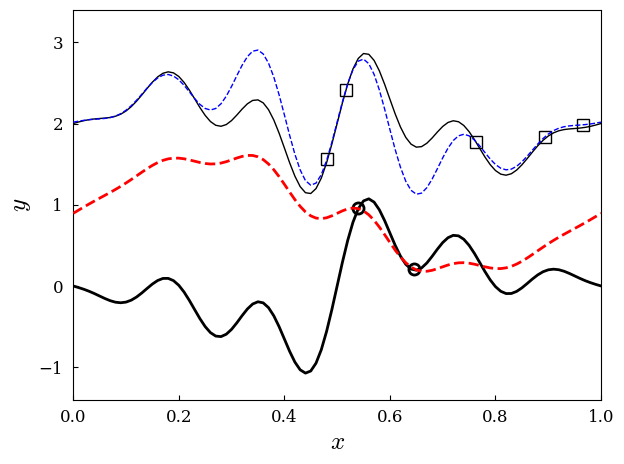

iSample = 7


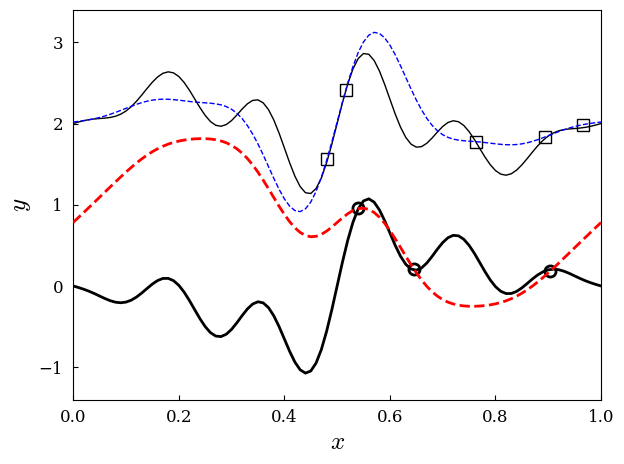

iSample = 8


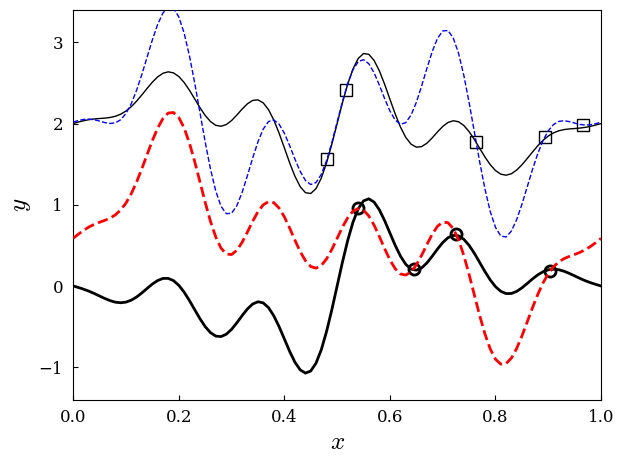

iSample = 9


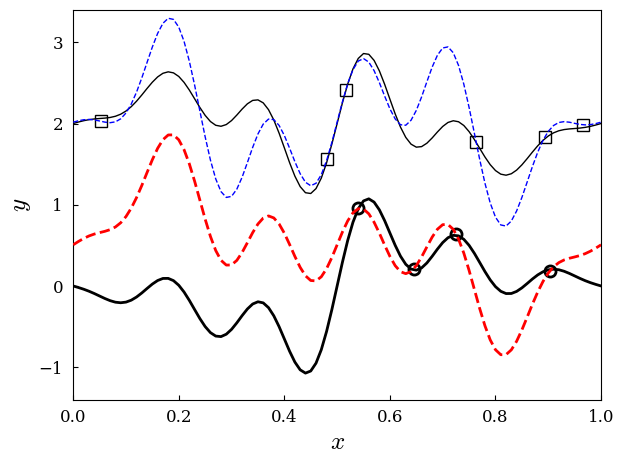

iSample = 10


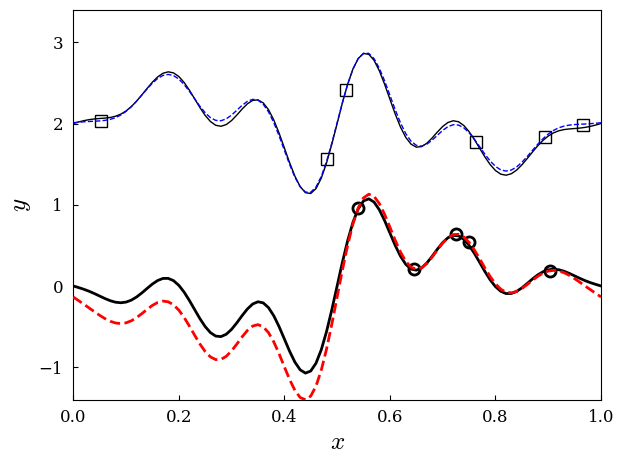

iSample = 11


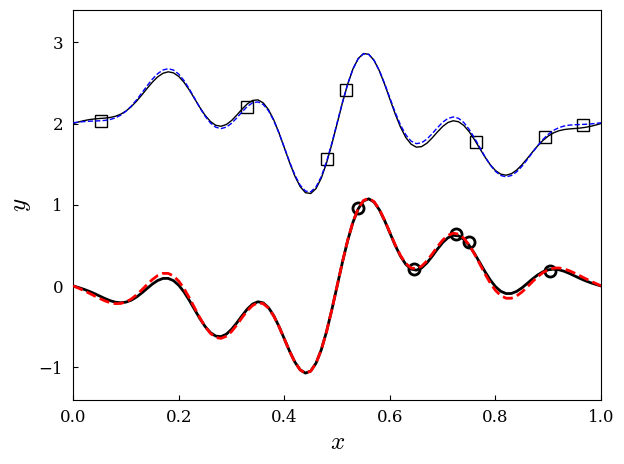

iSample = 12


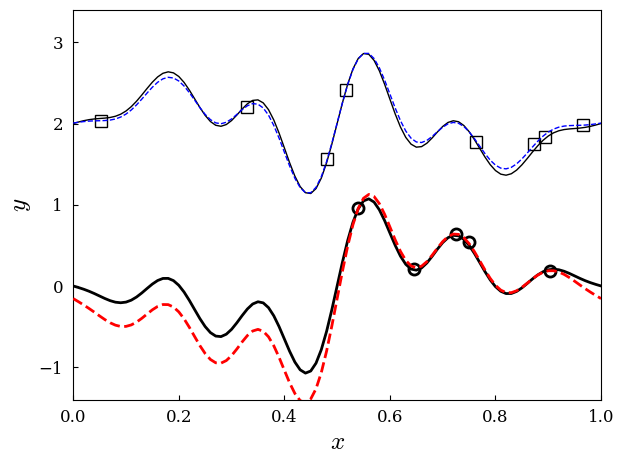

iSample = 13


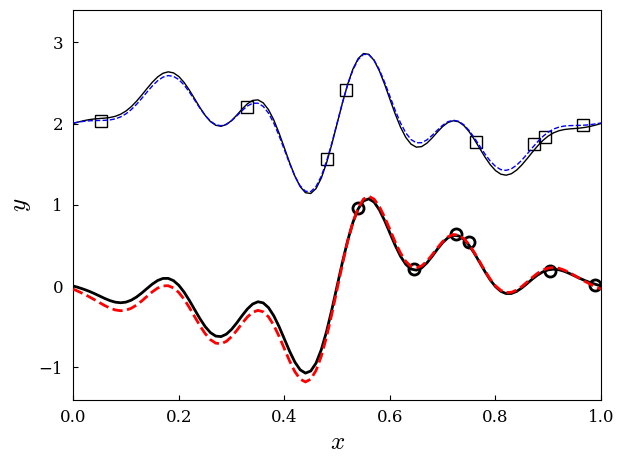

iSample = 14


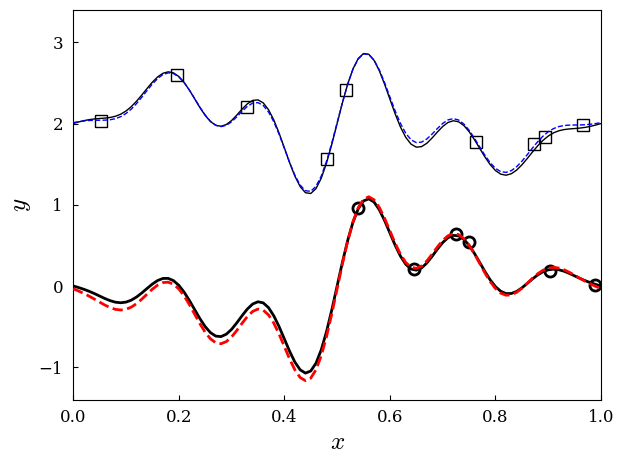

<Figure size 640x480 with 0 Axes>

In [18]:
nSampleMax = 15
filenameModelParameter = 'parameter_model_sine.xml'
filenameModelParameterOutput = 'parameter_model_sine_output.xml'
filenameCovarianceMatrix = 'covariance_matrix_sine.xml'
filenameCovarianceMatrixOutput = 'covariance_matrix_sine_output.xml'
fs = 12
fs_label = 18
fs_legend = 14
plt.rcParams['font.size'] = fs
color1 = 'blue'
color2 = 'red'
color3 = 'black'
rng = rnmanager.RandomNumberManager()
rng.restoreState()
xSample = []
ySample1 = []
ySample2 = []
xtrue = np.arange(0.0,1.0+1e-6,0.01)
ytrue1 = truemodel_sine_target1(xtrue)
ytrue2 = truemodel_sine_target2(xtrue)
da_sine = claude.CLAUDE()
da_sine.loadModelParameterFromFile(filenameModelParameter)
da_sine.loadCovarianceMatrixFromFile(filenameCovarianceMatrix)
x1 = np.arange(0.0,1.0+1e-6,0.01)
y1 = np.zeros((x1.shape[0],2), dtype=float)
for iSample in range(0,nSampleMax):
    print('iSample = {0}'.format(iSample))
    # random sampling.
    xRand = np.random.rand()
    aRand = np.random.rand()
    if (aRand > 0.4):
        yRand1 = truemodel_sine_target1(xRand) + np.random.normal(0.0,0.03)
        yRand2 = np.nan
    else:
        yRand1 = np.nan
        yRand2 = truemodel_sine_target2(xRand) + np.random.normal(0.0,0.10)
    xSample.append(xRand)
    ySample1.append(yRand1)
    ySample2.append(yRand2)
    # transform x to xHilbert.
    xHilbert = [np.sin(2*np.pi*i*xRand) for i in range(1,7)]
    da_sine.updateCovarianceMatrix(xHilbert,[yRand1,yRand2])
    # initial data.
    if(iSample < 5):
        continue
    da_sine.resetPrecisionMatrixMax()
    da_sine.findMaximumPosteriorProbability()
    for i in range(x1.shape[0]):
        y1[i] = da_sine.predict([np.sin(2*np.pi*j*x1[i]) for j in range(1,7)])
    p1, = plt.plot(x1,y1[:,0], linewidth=1, linestyle='dashed', color=color1, \
                marker='None', markersize=0, markeredgewidth=0, markeredgecolor=color1, markerfacecolor='None', clip_on=True, zorder=5, \
                label=r'$\mathrm{predict}$')
    p2, = plt.plot(x1,y1[:,1], linewidth=2, linestyle='dashed', color=color2, \
                marker='None', markersize=0, markeredgewidth=0, markeredgecolor=color2, markerfacecolor='None', clip_on=True, zorder=5, \
                label=r'$\mathrm{predict}$')
    psample1, = plt.plot(xSample[:iSample+1],ySample1[:iSample+1], linewidth=0, linestyle='solid', color=color3, \
                     marker='s', markersize=8, markeredgewidth=1, markeredgecolor=color3, markerfacecolor='None', clip_on=True, zorder=4, \
                     label=r'$\mathrm{sample}$')
    psample2, = plt.plot(xSample[:iSample+1],ySample2[:iSample+1], linewidth=0, linestyle='solid', color=color3, \
                     marker='o', markersize=8, markeredgewidth=2, markeredgecolor=color3, markerfacecolor='None', clip_on=True, zorder=4, \
                     label=r'$\mathrm{sample}$')
    ptrue1, = plt.plot(xtrue,ytrue1, linewidth=1, linestyle='solid', color=color3, \
                   marker='None', markersize=0, markeredgewidth=0, markeredgecolor=color3, markerfacecolor='None', clip_on=True, zorder=2, \
                   label=r'$\mathrm{true} \ \mathrm{model}$')
    ptrue2, = plt.plot(xtrue,ytrue2, linewidth=2, linestyle='solid', color=color3, \
                   marker='None', markersize=0, markeredgewidth=0, markeredgecolor=color3, markerfacecolor='None', clip_on=True, zorder=2, \
                   label=r'$\mathrm{true} \ \mathrm{model}$')
    # plt.legend([ptrue2,            psample2,            p], \
    #            [ptrue2.get_label(),psample2.get_label(),p.get_label()], \
    #            prop={'size':fs_legend}, numpoints=1, loc='upper left', ncol=1, framealpha=1.0)
    plt.xlabel(r'$x$', fontsize=fs_label)
    plt.ylabel(r'$y$', fontsize=fs_label)
    plt.xticks(np.arange(0.0,1.0+1e-6,0.2), y=-0.01)
    plt.yticks(np.arange(-1.0,3.5+1e-6,1.0), x=-0.01)
    plt.xlim(0.0,1.0)
    plt.ylim(-1.4,3.4)
    plt.tight_layout()
    plt.show()
    ## initialization.
    plt.figure()
da_sine.saveModelParameterToFile(filenameModelParameterOutput)
da_sine.saveCovarianceMatrixToFile(filenameCovarianceMatrixOutput)
rng.storeState()

### Bayesian optimization.

loadModelParameterFromFile: read header of model parameters.
loadModelParameterFromFile: read NumberDescriptor.
loadModelParameterFromFile: read DegreePolynomialDescriptor.
loadModelParameterFromFile: read Domain of descriptor.
loadModelParameterFromFile: read NumberTarget.
loadModelParameterFromFile: read DegreePolynomialTarget.
loadModelParameterFromFile: read ActiveVariable.
loadModelParameterFromFile: read InactiveVariable.
loadCovarianceMatrixFromFile: read covariance matrix from the file: covariance_matrix_sine_bo.xml
iSample = 0
(xRand,yRand1,yRand2) =  0.09689585763067698 2.1630254683253294 nan
iSample = 1
(xRand,yRand1,yRand2) =  0.31486784132951384 nan -0.41025076645543773
iSample = 2
(xRand,yRand1,yRand2) =  0.268782994595434 1.9829198865653221 nan
iSample = 3
(xRand,yRand1,yRand2) =  0.2703288877208331 nan -0.4939166006004051
iSample = 4
(xRand,yRand1,yRand2) =  0.0837292637963698 nan -0.14594400623533532
iSample = 5


/Users/harashima/.pyenv/versions/3.11.9/envs/test_claude/lib/python3.11/site-packages/claude/CLAUDE.py:1215: RuntimeWarning: invalid value encountered in log
  * (-self.dimensionAvailablePattern[idx] * np.log(2*np.pi) + np.log(detPrecisionMatrixAvailable) - rtmp1)


(xBO,yBO1,yBO2) =  0.43 1.2723289915007305 nan


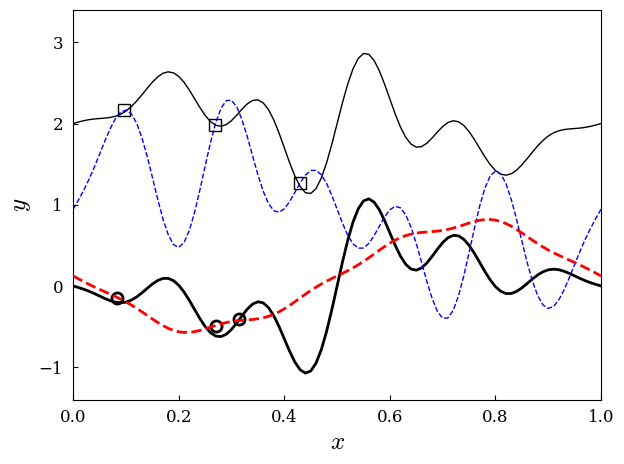

iSample = 6
(xBO,yBO1,yBO2) =  0.04 2.015805719199124 nan


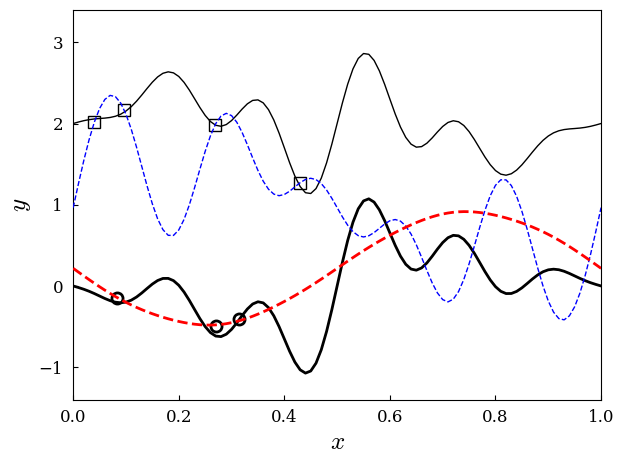

iSample = 7
(xBO,yBO1,yBO2) =  0.77 1.6994342104795603 nan


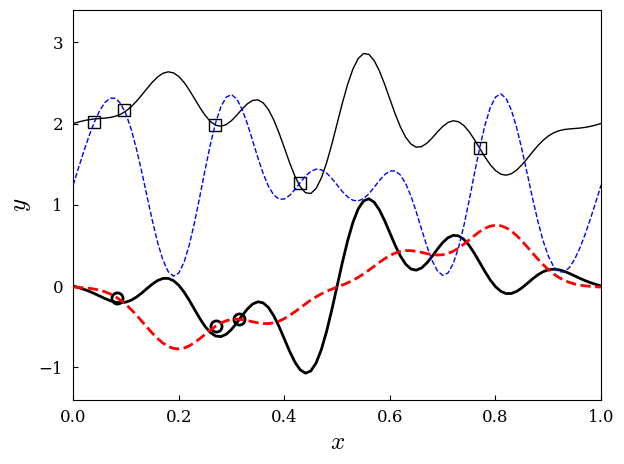

iSample = 8
(xBO,yBO1,yBO2) =  0.8 nan 0.038570683625395966


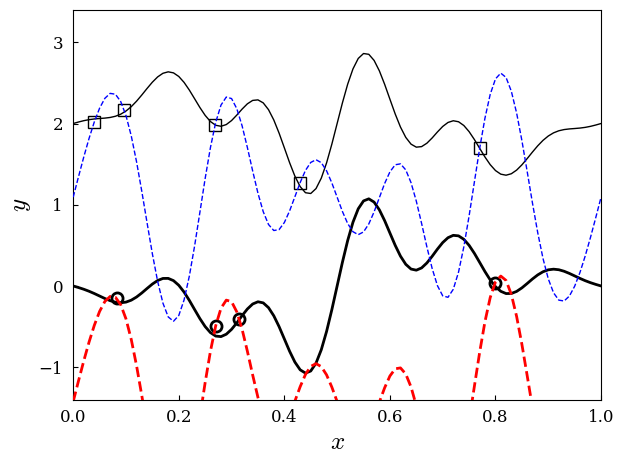

iSample = 9
(xBO,yBO1,yBO2) =  0.81 nan -0.07406561152835733


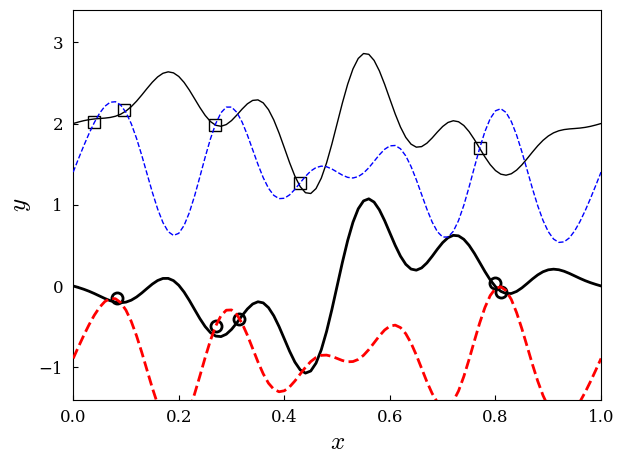

iSample = 10
(xBO,yBO1,yBO2) =  0.19 2.6231366533955733 nan


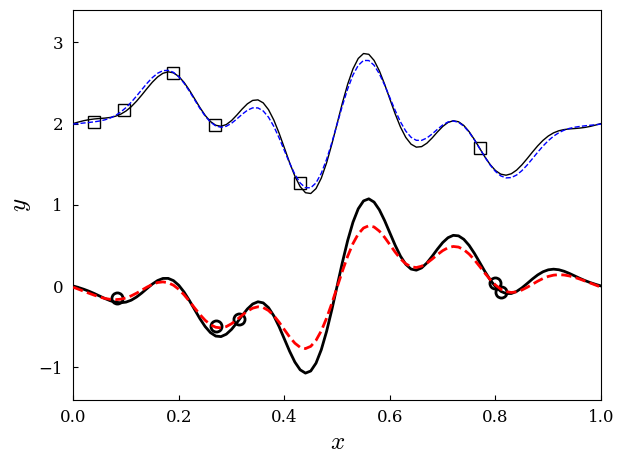

iSample = 11
(xBO,yBO1,yBO2) =  0.56 nan 1.0556915823126205


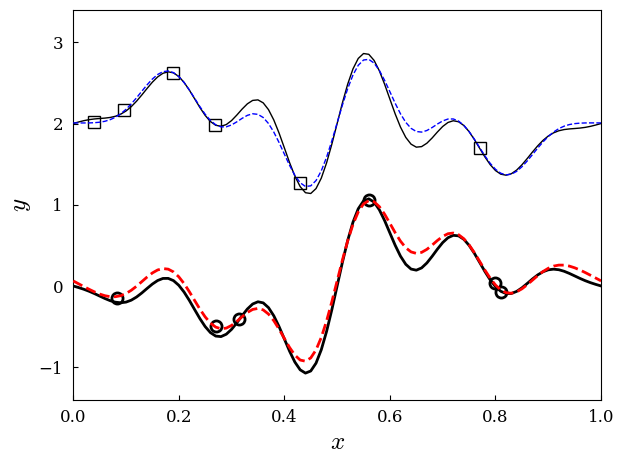

iSample = 12
(xBO,yBO1,yBO2) =  0.68 1.8312531454431613 nan


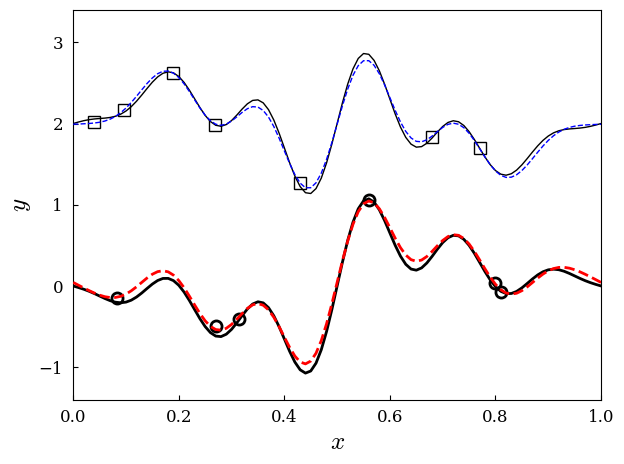

iSample = 13
(xBO,yBO1,yBO2) =  0.56 nan 1.3009525010816305


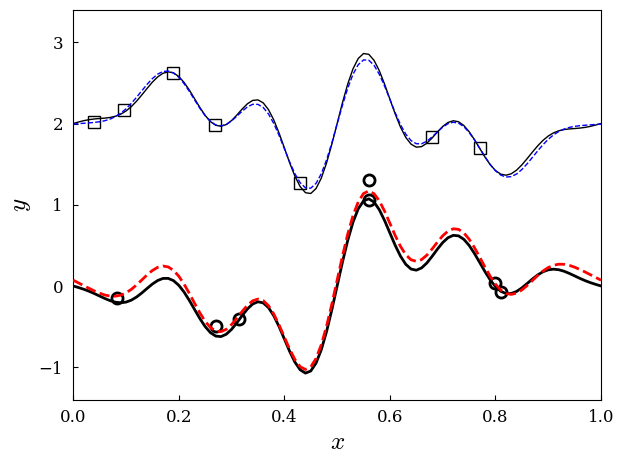

iSample = 14
(xBO,yBO1,yBO2) =  0.56 nan 0.9441495928794482


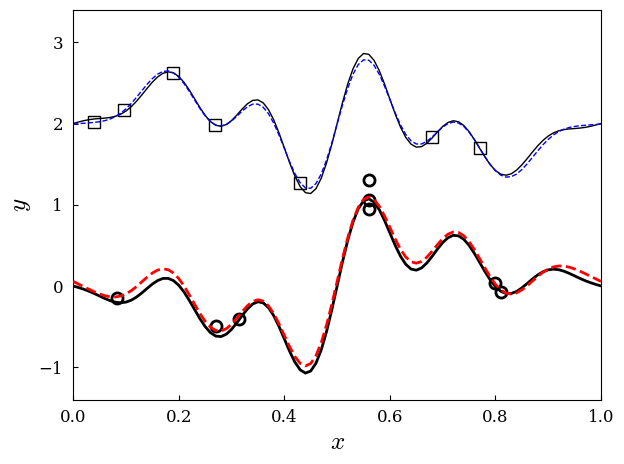

<Figure size 640x480 with 0 Axes>

In [20]:
nSampleMax = 15
filenameModelParameter = 'parameter_model_sine_bo.xml'
filenameModelParameterOutput = 'parameter_model_sine_bo_output.xml'
filenameCovarianceMatrix = 'covariance_matrix_sine_bo.xml'
filenameCovarianceMatrixOutput = 'covariance_matrix_sine_bo_output.xml'
fs = 12
fs_label = 18
fs_legend = 14
plt.rcParams['font.size'] = fs
color1 = 'blue'
color2 = 'red'
color3 = 'black'
rng = rnmanager.RandomNumberManager()
rng.restoreState()
xMesh = np.arange(0.0,1.0+1e-6,0.01)
xSample = []
ySample1 = []
ySample2 = []
xtrue = np.arange(0.0,1.0+1e-6,0.01)
ytrue1 = truemodel_sine_target1(xtrue)
ytrue2 = truemodel_sine_target2(xtrue)
da_sine_bo = claude.CLAUDE()
da_sine_bo.loadModelParameterFromFile(filenameModelParameter)
da_sine_bo.loadCovarianceMatrixFromFile(filenameCovarianceMatrix)
x1 = np.arange(0.0,1.0+1e-6,0.01)
y1 = np.zeros((x1.shape[0],2), dtype=float)
for iSample in range(0,nSampleMax):
    print('iSample = {0}'.format(iSample))
    if(iSample < 5):
        # random sampling.
        xRand = np.random.rand()
        aRand = np.random.rand()
        if (aRand > 0.4):
            yRand1 = truemodel_sine_target1(xRand) + np.random.normal(0.0,0.03)
            yRand2 = np.nan
        else:
            yRand1 = np.nan
            yRand2 = truemodel_sine_target2(xRand) + np.random.normal(0.0,0.10)
        xSample.append(xRand)
        ySample1.append(yRand1)
        ySample2.append(yRand2)
        # transform x to xHilbert.
        xHilbert = [np.sin(2*np.pi*i*xRand) for i in range(1,7)]
        da_sine_bo.updateCovarianceMatrix(xHilbert,[yRand1,yRand2])
        print('(xRand,yRand1,yRand2) = ',xRand,yRand1,yRand2)
        # initial data.
        if(iSample < 5):
            continue
    else:
        # Bayesian opt.
        ## Acquisition function.
        xHilbertList = np.array([[np.sin(2*np.pi*i*xMesh[idx]) for i in range(1,7)] for idx in range(xMesh.shape[0])])
        qeiList = da_sine_bo.acquisitionFunction(xHilbertList)
        ## first.
        aRand = np.random.rand()
        if (aRand > 0.4):
            iSampleMax = 0
            qeiMax = qeiList[0,0]
            for idx in range(1,qeiList.shape[0]):
                if (qeiMax < qeiList[idx,0]):
                    qeiMax = qeiList[idx,0]
                    iSampleMax = idx
            xBO = xMesh[iSampleMax]
            yBO1 = truemodel_sine_target1(xBO) + np.random.normal(0.0,0.03)
            yBO2 = np.nan
        else:
            ## second.
            iSampleMax = 0
            qeiMax = qeiList[0,1]
            for idx in range(1,qeiList.shape[0]):
                if (qeiMax < qeiList[idx,1]):
                    qeiMax = qeiList[idx,1]
                    iSampleMax = idx
            xBO = xMesh[iSampleMax]
            yBO1 = np.nan
            yBO2 = truemodel_sine_target2(xBO) + np.random.normal(0.0,0.10)
        xSample.append(xBO)
        ySample1.append(yBO1)
        ySample2.append(yBO2)
        xHilbert = [np.sin(2*np.pi*i*xBO) for i in range(1,7)]
        da_sine_bo.updateCovarianceMatrix(xHilbert,[yBO1,yBO2])
        print('(xBO,yBO1,yBO2) = ',xBO,yBO1,yBO2)
    da_sine_bo.resetPrecisionMatrixMax()
    da_sine_bo.findMaximumPosteriorProbability()
    for i in range(x1.shape[0]):
        y1[i] = da_sine_bo.predict([np.sin(2*np.pi*j*x1[i]) for j in range(1,7)])
    p1, = plt.plot(x1,y1[:,0], linewidth=1, linestyle='dashed', color=color1, \
                marker='None', markersize=0, markeredgewidth=0, markeredgecolor=color1, markerfacecolor='None', clip_on=True, zorder=5, \
                label=r'$\mathrm{predict}$')
    p2, = plt.plot(x1,y1[:,1], linewidth=2, linestyle='dashed', color=color2, \
                marker='None', markersize=0, markeredgewidth=0, markeredgecolor=color2, markerfacecolor='None', clip_on=True, zorder=5, \
                label=r'$\mathrm{predict}$')
    psample1, = plt.plot(xSample[:iSample+1],ySample1[:iSample+1], linewidth=0, linestyle='solid', color=color3, \
                     marker='s', markersize=8, markeredgewidth=1, markeredgecolor=color3, markerfacecolor='None', clip_on=True, zorder=4, \
                     label=r'$\mathrm{sample}$')
    psample2, = plt.plot(xSample[:iSample+1],ySample2[:iSample+1], linewidth=0, linestyle='solid', color=color3, \
                     marker='o', markersize=8, markeredgewidth=2, markeredgecolor=color3, markerfacecolor='None', clip_on=True, zorder=4, \
                     label=r'$\mathrm{sample}$')
    ptrue1, = plt.plot(xtrue,ytrue1, linewidth=1, linestyle='solid', color=color3, \
                   marker='None', markersize=0, markeredgewidth=0, markeredgecolor=color3, markerfacecolor='None', clip_on=True, zorder=2, \
                   label=r'$\mathrm{true} \ \mathrm{model}$')
    ptrue2, = plt.plot(xtrue,ytrue2, linewidth=2, linestyle='solid', color=color3, \
                   marker='None', markersize=0, markeredgewidth=0, markeredgecolor=color3, markerfacecolor='None', clip_on=True, zorder=2, \
                   label=r'$\mathrm{true} \ \mathrm{model}$')
    # plt.legend([ptrue2,            psample2,            p], \
    #            [ptrue2.get_label(),psample2.get_label(),p.get_label()], \
    #            prop={'size':fs_legend}, numpoints=1, loc='upper left', ncol=1, framealpha=1.0)
    plt.xlabel(r'$x$', fontsize=fs_label)
    plt.ylabel(r'$y$', fontsize=fs_label)
    plt.xticks(np.arange(0.0,1.0+1e-6,0.2), y=-0.01)
    plt.yticks(np.arange(-1.0,3.5+1e-6,1.0), x=-0.01)
    plt.xlim(0.0,1.0)
    plt.ylim(-1.4,3.4)
    plt.tight_layout()
    plt.show()
    ## initialization.
    plt.figure()
da_sine.saveModelParameterToFile(filenameModelParameterOutput)
da_sine.saveCovarianceMatrixToFile(filenameCovarianceMatrixOutput)
rng.storeState()

## Test 03: 2-dimensional system.

### Basis set.

In [21]:
def basis_sin(x):
    phi = [np.sin(2*np.pi*x[0]), \
           np.sin(2*np.pi*2*x[0]), \
           np.sin(2*np.pi*3*x[0]), \
           np.sin(2*np.pi*4*x[0]), \
           np.sin(2*np.pi*5*x[0]), \
           np.sin(2*np.pi*6*x[0]), \
           np.sin(2*np.pi*x[1]), \
           np.sin(2*np.pi*2*x[1]), \
           np.sin(2*np.pi*3*x[1]), \
           np.sin(2*np.pi*4*x[1]), \
           np.sin(2*np.pi*5*x[1]), \
           np.sin(2*np.pi*6*x[1])]
    return phi

### Definition: xMesh and xHilbertMesh.

In [22]:
nMesh1,nMesh2 = 31,31
x10,x11 = [0.0,1.0]
x20,x21 = [0.0,1.0]
dx1 = (x11-x10)/(nMesh1-1)
dx2 = (x21-x20)/(nMesh2-1)
xMesh1 = np.zeros((nMesh1,nMesh2), dtype=float)
xMesh2 = np.zeros((nMesh1,nMesh2), dtype=float)
xHilbertMesh = []
mapMeshIdx = []
for i2 in range(nMesh2):
    for i1 in range(nMesh1):
        xMesh1[i1,i2] = i1*dx1 + x10
        xMesh2[i1,i2] = i2*dx2 + x20
        xHilbert = basis_sin([xMesh1[i1,i2],xMesh2[i1,i2]])
        xHilbertMesh.append(list(xHilbert))
        mapMeshIdx.append([i1,i2])
xHilbertMesh = np.array(xHilbertMesh)

### True model.

In [23]:
def truemodel_sine_2d_target1(xt):
    y = 4.0 \
        + 0.2*np.sin(2*np.pi*xt[0]) \
        + 0.3*np.sin(2*np.pi*2*xt[0]) \
        - 0.2*np.sin(2*np.pi*3*xt[0]) \
        + 0.1*np.sin(2*np.pi*4*xt[0]) \
        - 0.3*np.sin(2*np.pi*5*xt[0]) \
        + 0.2*np.sin(2*np.pi*6*xt[0]) \
        + 0.4*np.sin(2*np.pi*xt[1]) * np.sin(2*np.pi*xt[0]) \
        - 0.1*np.sin(2*np.pi*xt[1]) \
        + 0.4*np.sin(2*np.pi*2*xt[1]) \
        - 0.2*np.sin(2*np.pi*2*xt[1]) * np.sin(2*np.pi*xt[0]) \
        + 0.1*np.sin(2*np.pi*3*xt[1]) \
        - 0.1*np.sin(2*np.pi*4*xt[1]) \
        + 0.1*np.sin(2*np.pi*5*xt[1]) \
        - 0.3*np.sin(2*np.pi*5*xt[1]) * np.sin(2*np.pi*3*xt[0]) \
        - 0.2*np.sin(2*np.pi*6*xt[1])
    return y
def truemodel_sine_2d_target2(xt):
    y = truemodel_sine_2d_target1(xt) - 4.0 - 0.6*np.sin(2*np.pi*xt[0])
    return y


In [24]:
# filenameoutput = 'truemodel.svg'
xTrue1 = np.zeros((nMesh1,nMesh2), dtype=float)
xTrue2 = np.zeros((nMesh1,nMesh2), dtype=float)
yTrue1 = np.zeros((nMesh1,nMesh2), dtype=float)
yTrue2 = np.zeros((nMesh1,nMesh2), dtype=float)
for i2 in range(nMesh2):
    for i1 in range(nMesh1):
        xTrue1[i1,i2] = i1*dx1 + x10
        xTrue2[i1,i2] = i2*dx2 + x20
        yTrue1[i1,i2] = truemodel_sine_2d_target1([xTrue1[i1,i2],xTrue2[i1,i2]])
        yTrue2[i1,i2] = truemodel_sine_2d_target2([xTrue1[i1,i2],xTrue2[i1,i2]])
yMaxMesh1 = np.max(yTrue1)
yMaxMesh2 = np.max(yTrue2)
print('yMax1 on mesh = {0:14.8f}'.format(yMaxMesh1))
print('yMax2 on mesh = {0:14.8f}'.format(yMaxMesh2))
ptrue1 = go.Surface(x=xTrue1,y=xTrue2,z=yTrue1, colorscale=['rgb( 99, 110, 250)','rgb( 99, 110, 250)'], opacity=0.8, showscale=False, \
                    contours = {'x':{'show':True, 'start':0.0, 'end':1.0, 'size':1./30., 'color':'black'}, \
                                'y':{'show':True, 'start':0.0, 'end':1.0, 'size':1./30., 'color':'black'}})
ptrue2 = go.Surface(x=xTrue1,y=xTrue2,z=yTrue2, colorscale=['rgb(239, 101,  72)','rgb(239, 101,  72)'], opacity=0.8, showscale=False, \
                    contours = {'x':{'show':True, 'start':0.0, 'end':1.0, 'size':1./30., 'color':'black'}, \
                                'y':{'show':True, 'start':0.0, 'end':1.0, 'size':1./30., 'color':'black'}})
fig = go.Figure(data=[ptrue2, \
                      ptrue1])
phi = 0.65
fig.update_layout(width=700,height=700, scene=dict(xaxis_title='x1',yaxis_title='x2',zaxis_title='y'), \
                                scene_camera=dict(up=dict(x=0,y=0,z=1), \
                                center=dict(x=0,y=0,z=-0.23), \
                                eye=dict(x=-2.0*np.cos(2*np.pi*phi),y=-2.0*np.sin(2*np.pi*phi),z=1.1)))
# fig.write_image(filenameoutput)
fig.show()
## initialization.

yMax1 on mesh =     5.96847313
yMax2 on mesh =     2.21251512


### Initial data.

In [25]:
nSampleInitial1,nSampleInitial2 = 5,5
e1,e2 = 0.3,1.0
rng = rnmanager.RandomNumberManager()
rng.restoreState()
xInit = np.random.rand(nSampleInitial1+nSampleInitial2,2)
yInit = np.zeros((xInit.shape[0],2), dtype=float)
for i in range(nSampleInitial1):
    yInit[i,0] = truemodel_sine_2d_target1(xInit[i]) + e1*(np.random.rand()-0.5)
    yInit[i,1] = np.nan
for i in range(nSampleInitial1,nSampleInitial1+nSampleInitial2):
    yInit[i,0] = np.nan
    yInit[i,1] = truemodel_sine_2d_target2(xInit[i]) + e2*(np.random.rand()-0.5)
rng.storeState()

### Simple Bayesian optimization with ordinary least square.

In [27]:
nSampleTotal1 = 50
filenameModelParameterOLS = 'parameter_model_sine_2d_bo_ols.xml'
filenameCovarianceMatrixOLS = 'covariance_matrix_sine_2d_bo_ols.xml'
xPredOLS1 = np.zeros(nMesh1*nMesh2, dtype=float)
xPredOLS2 = np.zeros(nMesh1*nMesh2, dtype=float)
yPredOLS2 = np.zeros(nMesh1*nMesh2, dtype=float)
idx = 0
for i2 in range(nMesh2):
    for i1 in range(nMesh1):
        xPredOLS1[idx] = i1*dx1 + x10
        xPredOLS2[idx] = i2*dx2 + x20
        idx += 1
## Initialize model.                                                                                                                
da_sine_2d_bo_ols = claude.CLAUDE()
da_sine_2d_bo_ols.loadModelParameterFromFile(filenameModelParameterOLS)
da_sine_2d_bo_ols.loadCovarianceMatrixFromFile(filenameCovarianceMatrixOLS)
da_sine_2d_bo_ols.setNSampleMonteCarlo(10)
xHilbert = np.zeros((nSampleInitial2, 12), dtype=float)
for iSample in range(xHilbert.shape[0]):
    xHilbert[iSample] = basis_sin(xInit[iSample+nSampleInitial1])
da_sine_2d_bo_ols.fit(xHilbert,yInit[nSampleInitial1:,1].reshape(-1,1))
xSample1 = list(xInit[nSampleInitial1:,0])
xSample2 = list(xInit[nSampleInitial1:,1])
ySample2 = list(yInit[nSampleInitial1:,1])
qeiMaxList = []
yMaxList2 = []
for iIter in range(5,nSampleTotal1):
    print('iIter = {0}'.format(iIter))
    ## Acquisition function.                                                                                                        
    qeiMesh = da_sine_2d_bo_ols.acquisitionFunction(xHilbertMesh)
    # Calculate argmax of acquisition function.                                                                                     
    iSampleMax = np.argmax(qeiMesh)
    iMax1,iMax2 = mapMeshIdx[iSampleMax]
    xSample1.append(xMesh1[iMax1,iMax2])
    xSample2.append(xMesh2[iMax1,iMax2])
    ySample2.append(truemodel_sine_2d_target2([xMesh1[iMax1,iMax2],xMesh2[iMax1,iMax2]]) + e2*(np.random.rand())-0.5)
    da_sine_2d_bo_ols.updateCovarianceMatrix(xHilbertMesh[iSampleMax],[ySample2[-1]])
    print('   x_calc = {0:14.8f}, {1:14.8f}'.format(xMesh1[iMax1,iMax2],xMesh2[iMax1,iMax2]))
    print('   y_calc = {0:14.8f}'.format(ySample2[-1]))
    print('   acquisition function = {0:14.8f}'.format(qeiMesh[iSampleMax,0]))
    qeiMaxList.append(qeiMesh[iSampleMax,0])
    yMaxList2.append(truemodel_sine_2d_target2([xMesh1[iMax1,iMax2],xMesh2[iMax1,iMax2]]))
    # Start regression.                                                                                                             
    da_sine_2d_bo_ols.resetPrecisionMatrixMax()
    da_sine_2d_bo_ols.findMaximumPosteriorProbability()

loadModelParameterFromFile: read header of model parameters.
loadModelParameterFromFile: read NumberDescriptor.
loadModelParameterFromFile: read DegreePolynomialDescriptor.
loadModelParameterFromFile: read Domain of descriptor.
loadModelParameterFromFile: read NumberTarget.
loadModelParameterFromFile: read DegreePolynomialTarget.
loadModelParameterFromFile: read ActiveVariable.
loadModelParameterFromFile: read InactiveVariable.
loadCovarianceMatrixFromFile: read covariance matrix from the file: covariance_matrix_sine_2d_bo_ols.xml
iIter = 5
   x_calc =     0.76666667,     0.70000000
   y_calc =     1.13252520
   acquisition function =     0.13817212
iIter = 6
   x_calc =     0.76666667,     0.66666667
   y_calc =     0.71371528
   acquisition function =     0.07528913
iIter = 7
   x_calc =     0.76666667,     0.70000000
   y_calc =     0.73393869
   acquisition function =     0.00328073
iIter = 8


/Users/harashima/.pyenv/versions/3.11.9/envs/test_claude/lib/python3.11/site-packages/claude/CLAUDE.py:1215: RuntimeWarning:

invalid value encountered in log



   x_calc =     0.10000000,     0.63333333
   y_calc =    -0.08391632
   acquisition function =     2.56469480
iIter = 9
   x_calc =     0.13333333,     0.53333333
   y_calc =     0.04146474
   acquisition function =     2.18876346
iIter = 10
   x_calc =     0.56666667,     0.86666667
   y_calc =     0.42103195
   acquisition function =     1.61026242
iIter = 11
   x_calc =     0.13333333,     0.86666667
   y_calc =    -0.67699868
   acquisition function =     1.11641709
iIter = 12
   x_calc =     0.10000000,     0.23333333
   y_calc =     0.14544816
   acquisition function =     0.57784592
iIter = 13
   x_calc =     0.93333333,     0.10000000
   y_calc =     1.05346340
   acquisition function =     0.81042567
iIter = 14
   x_calc =     0.93333333,     0.06666667
   y_calc =     0.79982490
   acquisition function =     0.54546724
iIter = 15
   x_calc =     0.56666667,     0.66666667
   y_calc =     1.63492762
   acquisition function =     0.39152431
iIter = 16
   x_calc =     0.5666666

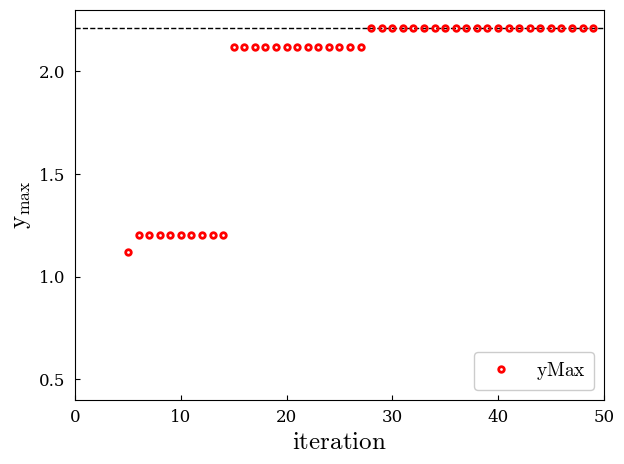

Done.


<Figure size 640x480 with 0 Axes>

In [28]:
fs = 12
fs_label = 18
fs_legend = 14
plt.rcParams['font.size'] = fs
color1 = 'red'
ytmp = np.array(yMaxList2)
for i in range(1,ytmp.shape[0]):
    ytmp[i] = max(ytmp[i-1],ytmp[i])
pyMax, = plt.plot(range(5,5+len(ytmp)),ytmp, linewidth=0, linestyle='None', color=color1, \
            marker='o', markersize=4, markeredgewidth=2, markeredgecolor=color1, markerfacecolor='None', clip_on=True, zorder=5, \
            label=r'$\mathrm{yMax}$')
plt.legend([pyMax], [pyMax.get_label()], \
            prop={'size':fs_legend}, numpoints=1, loc='lower right', ncol=1, framealpha=1.0)
plt.xlabel(r'$\mathrm{iteration}$', fontsize=fs_label)
plt.ylabel(r'$\mathrm{y}_{\mathrm{max}}$', fontsize=fs_label)
plt.xlim(0.0,50.0)
plt.xticks(np.arange(0.0,50.0+1e-6,10.0), y=-0.01)
plt.ylim(0.4,2.3)
plt.yticks(np.arange(0.5,2.3+1e-6,0.5), x=-0.01)
plt.hlines(yMaxMesh2,plt.xlim()[0],plt.xlim()[1], color='black', linestyle='dashed', lw=1.0)
plt.tight_layout()
plt.show()
## initialization.
plt.figure()
print("Done.")

### Bayesian optimization with data assimilation.

In [30]:
nSampleTotal1 = 20
nSamplePerIter1 = 3
filenameModelParameterCalc3 = 'parameter_model_sine_2d_bo_calc3.xml'
filenameCovarianceMatrixCalc3 = 'covariance_matrix_sine_2d_bo_calc3.xml'
xPredCalc31 = np.zeros(nMesh1*nMesh2, dtype=float)
xPredCalc32 = np.zeros(nMesh1*nMesh2, dtype=float)
yPredCalc32 = np.zeros(nMesh1*nMesh2, dtype=float)
idx = 0
for i2 in range(nMesh2):
    for i1 in range(nMesh1):
        xPredCalc31[idx] = i1*dx1 + x10
        xPredCalc32[idx] = i2*dx2 + x20
        idx += 1
da_sine_2d_bo_calc3 = claude.CLAUDE()
da_sine_2d_bo_calc3.loadModelParameterFromFile(filenameModelParameterCalc3)
da_sine_2d_bo_calc3.loadCovarianceMatrixFromFile(filenameCovarianceMatrixCalc3)
da_sine_2d_bo_calc3.setNSampleMonteCarlo(10)
## fit initial data.
xHilbert = np.zeros((nSampleInitial1 + nSampleInitial2, 12), dtype=float)
for iSample in range(xHilbert.shape[0]):
    xHilbert[iSample] = basis_sin(xInit[iSample])
da_sine_2d_bo_calc3.fit(xHilbert,yInit)
xSample1 = list(xInit[:,0])
xSample2 = list(xInit[:,1])
ySample1 = list(yInit[:,0])
ySample2 = list(yInit[:,1])
qeiMaxList = []
yMaxList2 = []
for iIter in range(5,nSampleTotal1):
    print('iIter = {0}'.format(iIter))
    # Sampling for model 1.
    print('   model 1')
    qeiMaxTmp = []
    yMaxTmp = []
    for iIter1 in range(nSamplePerIter1):
        print('      iIter = {0}-{1}'.format(iIter, iIter1))
        ## Acquisition function.
        qeiMesh = da_sine_2d_bo_calc3.acquisitionFunction(xHilbertMesh)
        # Calculate argmax of acquisition function.
        iSampleMax = np.argmax(qeiMesh[:,0])
        iMax1,iMax2 = mapMeshIdx[iSampleMax]
        xSample1.append(xMesh1[iMax1,iMax2])
        xSample2.append(xMesh2[iMax1,iMax2])
        ySample1.append(truemodel_sine_2d_target1([xMesh1[iMax1,iMax2],xMesh2[iMax1,iMax2]]) + e1*(np.random.rand())-0.5)
        ySample2.append(np.nan)
        da_sine_2d_bo_calc3.updateCovarianceMatrix(xHilbertMesh[iSampleMax],[ySample1[-1],np.nan])
        print('      x_calc = {0:14.8f}, {1:14.8f}'.format(xMesh1[iMax1,iMax2],xMesh2[iMax1,iMax2]))
        print('      y_calc = {0:14.8f}, {1}'.format(ySample1[-1],np.nan))
        print('      acquisition function = {0:14.8f}, {1:14.8f}'.format(qeiMesh[iSampleMax,0],qeiMesh[iSampleMax,1]))
        qeiMaxTmp.append(qeiMesh[iSampleMax])
        yMaxTmp.append([truemodel_sine_2d_target1([xMesh1[iMax1,iMax2],xMesh2[iMax1,iMax2]]), \
                        truemodel_sine_2d_target2([xMesh1[iMax1,iMax2],xMesh2[iMax1,iMax2]])])
    # Sampling for model 2.
    print('   model 2')
    ## Acquisition function.
    qeiMesh = da_sine_2d_bo_calc3.acquisitionFunction(xHilbertMesh)
    # Calculate argmax of acquisition function.
    iSampleMax = np.argmax(qeiMesh[:,1])
    iMax1,iMax2 = mapMeshIdx[iSampleMax]
    xSample1.append(xMesh1[iMax1,iMax2])
    xSample2.append(xMesh2[iMax1,iMax2])
    ySample1.append(np.nan)
    ySample2.append(truemodel_sine_2d_target2([xMesh1[iMax1,iMax2],xMesh2[iMax1,iMax2]]) + e2*(np.random.rand())-0.5)
    da_sine_2d_bo_calc3.updateCovarianceMatrix(xHilbertMesh[iSampleMax],[np.nan,ySample2[-1]])
    print('      x_calc = {0:14.8f}, {1:14.8f}'.format(xMesh1[iMax1,iMax2],xMesh2[iMax1,iMax2]))
    print('      y_calc = {0}, {1:14.8f}'.format(np.nan,ySample2[-1]))
    print('      acquisition function = {0:14.8f}, {1:14.8f}'.format(qeiMesh[iSampleMax,0],qeiMesh[iSampleMax,1]))
    qeiMaxTmp.append(qeiMesh[iSampleMax])
    yMaxTmp.append([truemodel_sine_2d_target1([xMesh1[iMax1,iMax2],xMesh2[iMax1,iMax2]]), \
                    truemodel_sine_2d_target2([xMesh1[iMax1,iMax2],xMesh2[iMax1,iMax2]])])
    qeiMaxList.append(copy.deepcopy(np.array(qeiMaxTmp).reshape(-1)))
    yMaxList2.append(copy.deepcopy(np.array(yMaxTmp).reshape(-1)))
    # Start regression.
    da_sine_2d_bo_calc3.resetPrecisionMatrixMax()
    da_sine_2d_bo_calc3.findMaximumPosteriorProbability()

loadModelParameterFromFile: read header of model parameters.
loadModelParameterFromFile: read NumberDescriptor.
loadModelParameterFromFile: read DegreePolynomialDescriptor.
loadModelParameterFromFile: read Domain of descriptor.
loadModelParameterFromFile: read NumberTarget.
loadModelParameterFromFile: read DegreePolynomialTarget.
loadModelParameterFromFile: read ActiveVariable.
loadModelParameterFromFile: read InactiveVariable.
loadCovarianceMatrixFromFile: read covariance matrix from the file: covariance_matrix_sine_2d_bo_calc3.xml
iIter = 5
   model 1
      iIter = 5-0
      x_calc =     0.13333333,     0.80000000
      y_calc =     3.74960912, nan
      acquisition function =     0.15692958,     0.00000000
      iIter = 5-1
      x_calc =     0.13333333,     0.80000000
      y_calc =     3.74341727, nan
      acquisition function =     0.47745681,     0.02413835
      iIter = 5-2
      x_calc =     0.13333333,     0.80000000
      y_calc =     3.79955076, nan
      acquisition funct

/Users/harashima/.pyenv/versions/3.11.9/envs/test_claude/lib/python3.11/site-packages/claude/CLAUDE.py:1578: RuntimeWarning:

invalid value encountered in sqrt



      x_calc =     1.00000000,     0.00000000
      y_calc =     3.60427275, nan
      acquisition function =            nan,     0.00000000
      iIter = 12-1
      x_calc =     0.13333333,     0.40000000
      y_calc =     4.05874371, nan
      acquisition function =     0.19423465,     0.00000000
      iIter = 12-2
      x_calc =     0.13333333,     0.36666667
      y_calc =     3.96973699, nan
      acquisition function =     0.24137792,     0.00000000
   model 2
      x_calc =     0.56666667,     0.73333333
      y_calc = nan,     0.89415636
      acquisition function =     0.09653240,     0.00412246
Warning in findMaximumPosteriorProbability: maximization for posterior probability is not converged.
iIter = 13
   model 1
      iIter = 13-0
      x_calc =     0.80000000,     0.13333333
      y_calc =     3.77289949, nan
      acquisition function =     0.07482304,     0.00000000
      iIter = 13-1
      x_calc =     0.33333333,     0.43333333
      y_calc =     4.11370684, nan
    

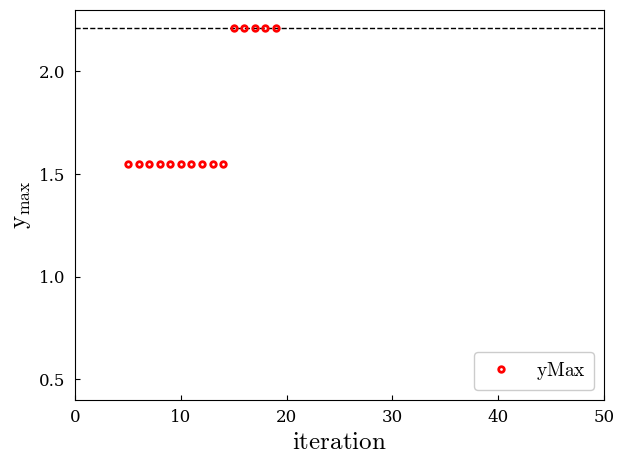

Done.


<Figure size 640x480 with 0 Axes>

In [31]:
fs = 12
fs_label = 18
fs_legend = 14
plt.rcParams['font.size'] = fs
color1 = 'red'
ytmp = np.array([yMaxList2[i][-1] for i in range(len(yMaxList2))])
for i in range(1,ytmp.shape[0]):
    ytmp[i] = max(ytmp[i-1],ytmp[i])
pyMax, = plt.plot(range(5,5+len(ytmp)),ytmp, linewidth=0, linestyle='None', color=color1, \
            marker='o', markersize=4, markeredgewidth=2, markeredgecolor=color1, markerfacecolor='None', clip_on=True, zorder=5, \
            label=r'$\mathrm{yMax}$')
plt.legend([pyMax], [pyMax.get_label()], \
            prop={'size':fs_legend}, numpoints=1, loc='lower right', ncol=1, framealpha=1.0)
plt.xlabel(r'$\mathrm{iteration}$', fontsize=fs_label)
plt.ylabel(r'$\mathrm{y}_{\mathrm{max}}$', fontsize=fs_label)
plt.xlim(0.0,50.0)
plt.xticks(np.arange(0.0,50.0+1e-6,10.0), y=-0.01)
plt.ylim(0.4,2.3)
plt.yticks(np.arange(0.5,2.3+1e-6,0.5), x=-0.01)
plt.hlines(yMaxMesh2,plt.xlim()[0],plt.xlim()[1], color='black', linestyle='dashed', lw=1.0)
plt.tight_layout()
plt.show()
## initialization.
plt.figure()
print("Done.")

# Direct format of initialization.

## Test 00: regression.

In [5]:
def truemodel_target1(xt):
    return 2.0 - xt + 5.0*(xt-0.7)**2 + 20.0*(xt-0.5)**3
def truemodel_target2(xt):
    return truemodel_target1(xt) - 1.5

In [6]:
da = claude.CLAUDE(nDescriptor=1, \
                   nTarget=2, \
                   degreePolynomialDescriptor = np.array([[0],[1],[2],[3]]), \
                   degreeActiveDescriptor = [[[0],[0,1]]])

print('read data for covariance matrix.')
datatable = pd.read_csv('exampledata.txt',comment='#',delimiter='\s+',na_values='----').values
xSample = datatable[:,0].reshape(-1,1)
ySample = datatable[:,(1,2)]
da.fit(xSample,ySample)

print('save model parameters.')
da.saveModelParameterToFile('parameter_model_output_1.xml')
print('save covariance matrix components.')
da.saveCovarianceMatrixToFile('covariance_matrix_output_1.xml')

read data for covariance matrix.
Warning in findMaximumPosteriorProbability: maximization for posterior probability is not converged.
save model parameters.
save covariance matrix components.


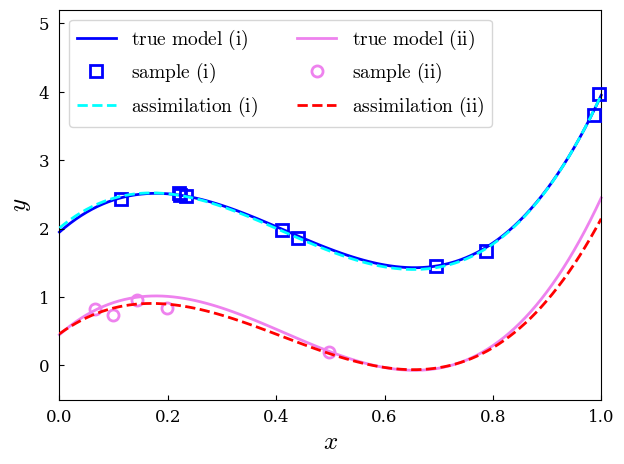

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [7]:
filenameinput1 = 'exampledata.txt'
# filenameoutput = 'predictcurve.pdf'
fs = 12
fs_label = 18
fs_legend = 14
plt.rcParams['font.size'] = fs
data1 = pd.read_csv(filenameinput1,comment='#',delimiter='\s+',na_values='----').values
xsample = data1[:,0]
ysample1 = data1[:,1]
ysample2 = data1[:,2]
nSample = len(xsample)
xtrue1 = np.arange(0.0,1.0+1e-6,0.01)
ytrue1 = truemodel_target1(xtrue1)
xtrue2 = np.arange(0.0,1.0+1e-6,0.01)
ytrue2 = truemodel_target2(xtrue2)
xpred = np.arange(0.0,1.0+1e-6,0.01)
ypred = da.predict(xpred)
ypred1 = ypred[:,0]
ypred2 = ypred[:,1]
colorTrue1 = 'blue'
colorTrue2 = 'violet'
colorPred1 = 'cyan'
colorPred2 = 'red'
ptrue1, = plt.plot(xtrue1,ytrue1, linewidth=2, linestyle='solid', color=colorTrue1, \
                   marker='None', markersize=0, markeredgewidth=0, markeredgecolor=colorTrue1, markerfacecolor='None', clip_on=False, zorder=1, \
                   label=r'$\mathrm{true} \ \mathrm{model} \ (\mathrm{i})$')
ptrue2, = plt.plot(xtrue2,ytrue2, linewidth=2, linestyle='solid', color=colorTrue2, \
                   marker='None', markersize=0, markeredgewidth=0, markeredgecolor=colorTrue2, markerfacecolor='None', clip_on=False, zorder=2, \
                   label=r'$\mathrm{true} \ \mathrm{model} \ (\mathrm{ii})$')
psample1, = plt.plot(xsample,ysample1, linewidth=0, linestyle='solid', color=colorTrue1, \
                     marker='s', markersize=8, markeredgewidth=2, markeredgecolor=colorTrue1, markerfacecolor='None', clip_on=False, zorder=3, \
                     label=r'$\mathrm{sample} \ (\mathrm{i})$')
psample2, = plt.plot(xsample,ysample2, linewidth=0, linestyle='solid', color=colorTrue2, \
                     marker='o', markersize=8, markeredgewidth=2, markeredgecolor=colorTrue2, markerfacecolor='None', clip_on=False, zorder=4, \
                     label=r'$\mathrm{sample} \ (\mathrm{ii})$')
ppred1, = plt.plot(xpred,ypred1, linewidth=2, linestyle='dashed', color=colorPred1, \
                   marker='None', markersize=0, markeredgewidth=0, markeredgecolor=colorPred1, markerfacecolor='None', clip_on=True, zorder=5, \
                   label=r'$\mathrm{assimilation} \ (\mathrm{i})$')
ppred2, = plt.plot(xpred,ypred2, linewidth=2, linestyle='dashed', color=colorPred2, \
                   marker='None', markersize=0, markeredgewidth=0, markeredgecolor=colorPred2, markerfacecolor='None', clip_on=True, zorder=6, \
                   label=r'$\mathrm{assimilation} \ (\mathrm{ii})$')
plt.legend([ptrue1,            psample1,            ppred1,            ptrue2,            psample2,            ppred2], \
           [ptrue1.get_label(),psample1.get_label(),ppred1.get_label(),ptrue2.get_label(),psample2.get_label(),ppred2.get_label()], \
           prop={'size':fs_legend}, numpoints=1, loc='upper left', ncol=2)
plt.xlabel(r'$x$', fontsize=fs_label)
plt.ylabel(r'$y$', fontsize=fs_label)
plt.xticks(np.arange(0.0,1.0+1e-6,0.2), y=-0.01)
plt.yticks(np.arange(0.0,5.0+1e-6,1.0), x=-0.01)
plt.xlim(0.0,1.0)
plt.ylim(-0.5,5.2)
plt.tight_layout()
plt.show()
# plt.savefig(filenameoutput, transparent=True)
## initialization.
plt.figure()

## Test 01: statistics.

In [10]:
def truemodel_sparse_target1(xt):
    return 2.0 - xt + 5.0*(xt-0.7)**2 + 20.0*(xt-0.5)**3
def truemodel_sparse_target2(xt):
    return truemodel_sparse_target1(xt) - 1.5

In [11]:
da_sparse = claude.CLAUDE(nDescriptor=1, \
                          nTarget=2, \
                          degreePolynomialDescriptor = np.array([[0],[1],[2],[3]]), \
                          degreeActiveDescriptor = [[[0],[0,1]]])

print('read data for covariance matrix.')
datatable = pd.read_csv('exampledata_sparse.txt',comment='#',delimiter='\s+',na_values='----').values
xSample = datatable[:,0].reshape(-1,1)
ySample = datatable[:,(1,2)]
da_sparse.fit(xSample,ySample)

print('save model parameters.')
da_sparse.saveModelParameterToFile('parameter_model_sparse_output_1.xml')
print('save covariance matrix components.')
da_sparse.saveCovarianceMatrixToFile('covariance_matrix_sparse_output_1.xml')

read data for covariance matrix.
save model parameters.
save covariance matrix components.


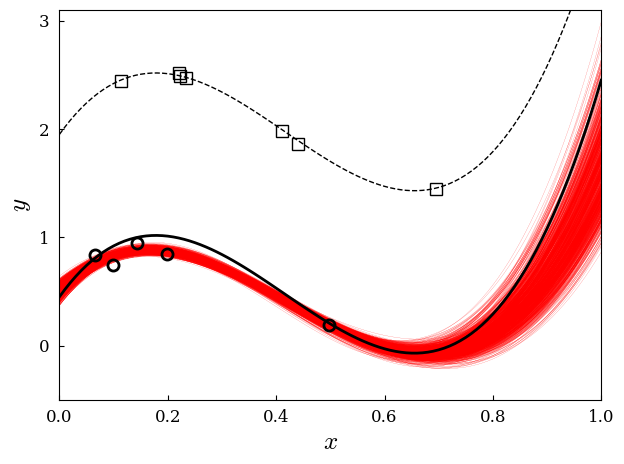

<Figure size 640x480 with 0 Axes>

In [12]:
filenameinput1 = 'exampledata_sparse.txt'
filenameModelParameter = 'parameter_model_sparse_output_1.xml'
filenameCovarianceMatrix = 'covariance_matrix_sparse_output_1.xml'
# filenameoutput = 'predictcurve_statistics_sparse.pdf'
fs = 12
fs_label = 18
fs_legend = 14
plt.rcParams['font.size'] = fs
rng = rnmanager.RandomNumberManager()
rng.restoreState()
color1 = 'red'
nStatistics = 1000
precisionMatrix = da_sparse.getPrecisionMatrixMax()
x1 = np.arange(0.0,1.0+1e-6,0.01)
y1 = np.zeros((x1.shape[0],2), dtype=float)
for iStatistics in range(nStatistics):
    da_sparse.transitionPrecisionMatrix(precisionMatrix)
    for i in range(x1.shape[0]):
        y1[i] = da_sparse.predict([x1[i]], precisionMatrix)
    p, = plt.plot(x1,y1[:,1], linewidth=0.1, linestyle='solid', color=color1, \
                marker='None', markersize=0, markeredgewidth=0, markeredgecolor=color1, markerfacecolor='None', clip_on=True, zorder=1, \
                label=r'$\mathrm{predict}$')
data1 = pd.read_csv(filenameinput1,comment='#',delimiter='\s+',na_values='----').values
xsample = data1[:,0]
ysample1 = data1[:,1]
ysample2 = data1[:,2]
xtrue = np.arange(0.0,1.0+1e-6,0.01)
ytrue1 = truemodel_sparse_target1(xtrue)
ytrue2 = truemodel_sparse_target2(xtrue)
color2 = 'black'
psample1, = plt.plot(xsample,ysample1, linewidth=0, linestyle='solid', color=color2, \
                     marker='s', markersize=8, markeredgewidth=1, markeredgecolor=color2, markerfacecolor='None', clip_on=True, zorder=4, \
                     label=r'$\mathrm{sample}$')
psample2, = plt.plot(xsample,ysample2, linewidth=0, linestyle='solid', color=color2, \
                     marker='o', markersize=8, markeredgewidth=2, markeredgecolor=color2, markerfacecolor='None', clip_on=True, zorder=4, \
                     label=r'$\mathrm{sample}$')
ptrue1, = plt.plot(xtrue,ytrue1, linewidth=1, linestyle='dashed', color=color2, \
                   marker='None', markersize=0, markeredgewidth=0, markeredgecolor=color2, markerfacecolor='None', clip_on=True, zorder=2, \
                   label=r'$\mathrm{true} \ \mathrm{model}$')
ptrue2, = plt.plot(xtrue,ytrue2, linewidth=2, linestyle='solid', color=color2, \
                   marker='None', markersize=0, markeredgewidth=0, markeredgecolor=color2, markerfacecolor='None', clip_on=True, zorder=2, \
                   label=r'$\mathrm{true} \ \mathrm{model}$')
# plt.legend([ptrue2,            psample2,            p], \
#            [ptrue2.get_label(),psample2.get_label(),p.get_label()], \
#            prop={'size':fs_legend}, numpoints=1, loc='upper left', ncol=1, framealpha=1.0)
plt.xlabel(r'$x$', fontsize=fs_label)
plt.ylabel(r'$y$', fontsize=fs_label)
plt.xticks(np.arange(0.0,1.0+1e-6,0.2), y=-0.01)
plt.yticks(np.arange(0.0,3.0+1e-6,1.0), x=-0.01)
plt.xlim(0.0,1.0)
plt.ylim(-0.5,3.1)
plt.tight_layout()
# plt.savefig(filenameoutput, transparent=True)
plt.show()
## initialization.
plt.figure()
rng.storeState()

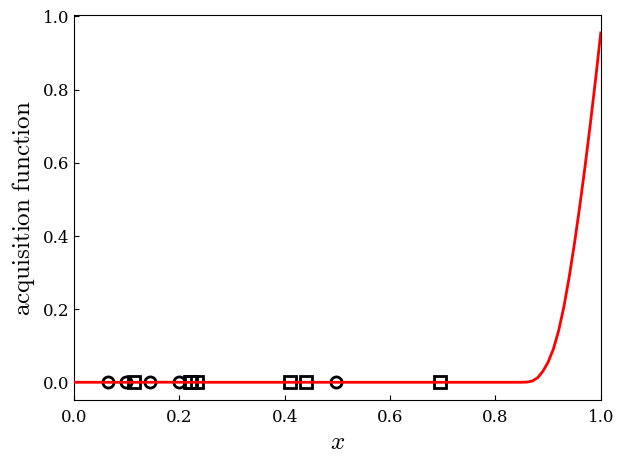

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [11]:
filenameinput1 = 'exampledata_sparse.txt'
# filenameoutput = 'acquisitionfunction_sparse.pdf'
fs = 12
fs_label = 18
fs_legend = 14
plt.rcParams['font.size'] = fs
data1 = pd.read_csv(filenameinput1,comment='#',delimiter='\s+',na_values='----').values
xsample = data1[:,0]
ysample1 = data1[:,1]-data1[:,1]
ysample2 = data1[:,2]-data1[:,2]
nSample = len(xsample)
xacqui = np.arange(0.0,1.0+1e-6,0.01)
yacqui = da_sparse.acquisitionFunction(xacqui.reshape(-1,1))
yacquiSD = yacqui[:,0]
yacquiEI = yacqui[:,1]
color0 = 'black'
color1 = 'red'
color2 = 'blue'
psample1, = plt.plot(xsample,ysample1, linewidth=0, linestyle='solid', color=color0, \
                     marker='s', markersize=8, markeredgewidth=2, markeredgecolor=color0, markerfacecolor='None', clip_on=False, zorder=3, \
                     label=r'$\mathrm{sample} \ (\mathrm{i})$')
psample2, = plt.plot(xsample,ysample2, linewidth=0, linestyle='solid', color=color0, \
                     marker='o', markersize=8, markeredgewidth=2, markeredgecolor=color0, markerfacecolor='None', clip_on=False, zorder=4, \
                     label=r'$\mathrm{sample} \ (\mathrm{ii})$')
pacquiEI, = plt.plot(xacqui,yacquiEI, linewidth=2, linestyle='solid', color=color1, \
                   marker='None', markersize=0, markeredgewidth=0, markeredgecolor=color1, markerfacecolor='None', clip_on=True, zorder=5, \
                   label=r'$\mathrm{acquisition} \ (\mathrm{function})$')
# pacquiSD, = plt.plot(xacqui,yacquiSD, linewidth=2, linestyle='solid', color=color2, \
#                    marker='None', markersize=0, markeredgewidth=0, markeredgecolor=color1, markerfacecolor='None', clip_on=True, zorder=5, \
#                    label=r'$\mathrm{acquisition} \ (\mathrm{function})$')
plt.xlabel(r'$x$', fontsize=fs_label)
plt.ylabel(r'$\mathrm{acquisition} \ \mathrm{function}$', fontsize=fs_label)
plt.xticks(np.arange(0.0,1.0+1e-6,0.2), y=-0.01)
# plt.yticks(np.arange(0.0,5.0+1e-6,1.0), x=-0.01)
plt.xlim(0.0,1.0)
# plt.ylim(-0.5,5.2)
plt.tight_layout()
# plt.savefig(filenameoutput, transparent=True)
plt.show()
## initialization.
plt.figure()

## Test 01.1: statistics.

In [13]:
def truemodel_sparse_1_target1(xt):
    return 2.0 - xt + 5.0*(xt-0.7)**2 + 20.0*(xt-0.5)**3
def truemodel_sparse_1_target2(xt):
    return truemodel_sparse_1_target1(xt) - 1.5

In [14]:
da_sparse_1 = claude.CLAUDE(nDescriptor=1, \
                            nTarget=2, \
                            degreePolynomialDescriptor = np.array([[0],[1],[2],[3]]), \
                            degreeActiveDescriptor = [[[0],[0,1]]])

print('read data for covariance matrix.')
datatable = pd.read_csv('exampledata_sparse_1.txt',comment='#',delimiter='\s+',na_values='----').values
xSample = datatable[:,0].reshape(-1,1)
ySample = datatable[:,(1,2)]
da_sparse_1.fit(xSample,ySample)

print('save model parameters.')
da_sparse_1.saveModelParameterToFile('parameter_model_sparse_1_output_1.xml')
print('save covariance matrix components.')
da_sparse_1.saveCovarianceMatrixToFile('covariance_matrix_sparse_1_output_1.xml')

read data for covariance matrix.
save model parameters.
save covariance matrix components.


/Users/harashima/.pyenv/versions/3.11.9/envs/test_claude/lib/python3.11/site-packages/claude/CLAUDE.py:1215: RuntimeWarning: invalid value encountered in log
  * (-self.dimensionAvailablePattern[idx] * np.log(2*np.pi) + np.log(detPrecisionMatrixAvailable) - rtmp1)


/Users/harashima/.pyenv/versions/3.11.9/envs/test_claude/lib/python3.11/site-packages/claude/CLAUDE.py:1419: RuntimeWarning: overflow encountered in exp
  if (np.random.rand() < np.exp(dp)):


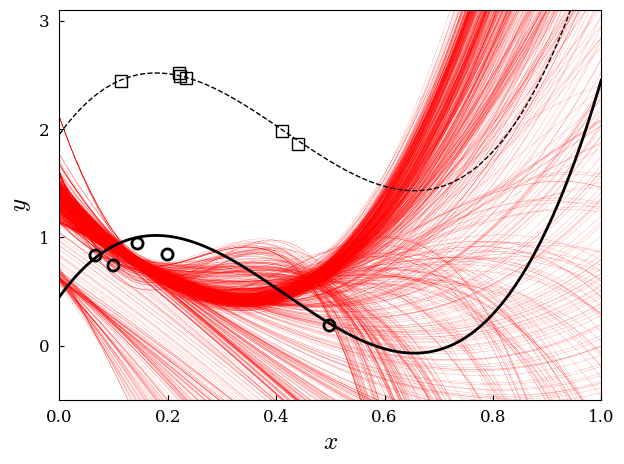

<Figure size 640x480 with 0 Axes>

In [15]:
filenameinput1 = 'exampledata_sparse_1.txt'
filenameModelParameter = 'parameter_model_sparse_1_output_1.xml'
filenameCovarianceMatrix = 'covariance_matrix_sparse_1_output_1.xml'
# filenameoutput = 'predictcurve_statistics_sparse.pdf'
fs = 12
fs_label = 18
fs_legend = 14
plt.rcParams['font.size'] = fs
rng = rnmanager.RandomNumberManager()
rng.restoreState()
color1 = 'red'
nStatistics = 1000
precisionMatrix = da_sparse_1.getPrecisionMatrixMax()
x1 = np.arange(0.0,1.0+1e-6,0.01)
y1 = np.zeros((x1.shape[0],2), dtype=float)
for iStatistics in range(nStatistics):
    da_sparse_1.transitionPrecisionMatrix(precisionMatrix)
    for i in range(x1.shape[0]):
        y1[i] = da_sparse_1.predict([x1[i]], precisionMatrix)
    p, = plt.plot(x1,y1[:,1], linewidth=0.1, linestyle='solid', color=color1, \
                marker='None', markersize=0, markeredgewidth=0, markeredgecolor=color1, markerfacecolor='None', clip_on=True, zorder=1, \
                label=r'$\mathrm{predict}$')
data1 = pd.read_csv(filenameinput1,comment='#',delimiter='\s+',na_values='----').values
xsample = data1[:,0]
ysample1 = data1[:,1]
ysample2 = data1[:,2]
xtrue = np.arange(0.0,1.0+1e-6,0.01)
ytrue1 = truemodel_sparse_target1(xtrue)
ytrue2 = truemodel_sparse_target2(xtrue)
color2 = 'black'
psample1, = plt.plot(xsample,ysample1, linewidth=0, linestyle='solid', color=color2, \
                     marker='s', markersize=8, markeredgewidth=1, markeredgecolor=color2, markerfacecolor='None', clip_on=True, zorder=4, \
                     label=r'$\mathrm{sample}$')
psample2, = plt.plot(xsample,ysample2, linewidth=0, linestyle='solid', color=color2, \
                     marker='o', markersize=8, markeredgewidth=2, markeredgecolor=color2, markerfacecolor='None', clip_on=True, zorder=4, \
                     label=r'$\mathrm{sample}$')
ptrue1, = plt.plot(xtrue,ytrue1, linewidth=1, linestyle='dashed', color=color2, \
                   marker='None', markersize=0, markeredgewidth=0, markeredgecolor=color2, markerfacecolor='None', clip_on=True, zorder=2, \
                   label=r'$\mathrm{true} \ \mathrm{model}$')
ptrue2, = plt.plot(xtrue,ytrue2, linewidth=2, linestyle='solid', color=color2, \
                   marker='None', markersize=0, markeredgewidth=0, markeredgecolor=color2, markerfacecolor='None', clip_on=True, zorder=2, \
                   label=r'$\mathrm{true} \ \mathrm{model}$')
# plt.legend([ptrue2,            psample2,            p], \
#            [ptrue2.get_label(),psample2.get_label(),p.get_label()], \
#            prop={'size':fs_legend}, numpoints=1, loc='upper left', ncol=1, framealpha=1.0)
plt.xlabel(r'$x$', fontsize=fs_label)
plt.ylabel(r'$y$', fontsize=fs_label)
plt.xticks(np.arange(0.0,1.0+1e-6,0.2), y=-0.01)
plt.yticks(np.arange(0.0,3.0+1e-6,1.0), x=-0.01)
plt.xlim(0.0,1.0)
plt.ylim(-0.5,3.1)
plt.tight_layout()
# plt.savefig(filenameoutput, transparent=True)
plt.show()
## initialization.
plt.figure()
rng.storeState()

/Users/harashima/.pyenv/versions/3.11.9/envs/test_claude/lib/python3.11/site-packages/claude/CLAUDE.py:1419: RuntimeWarning: overflow encountered in exp
  if (np.random.rand() < np.exp(dp)):
/Users/harashima/.pyenv/versions/3.11.9/envs/test_claude/lib/python3.11/site-packages/claude/CLAUDE.py:1215: RuntimeWarning: invalid value encountered in log
  * (-self.dimensionAvailablePattern[idx] * np.log(2*np.pi) + np.log(detPrecisionMatrixAvailable) - rtmp1)


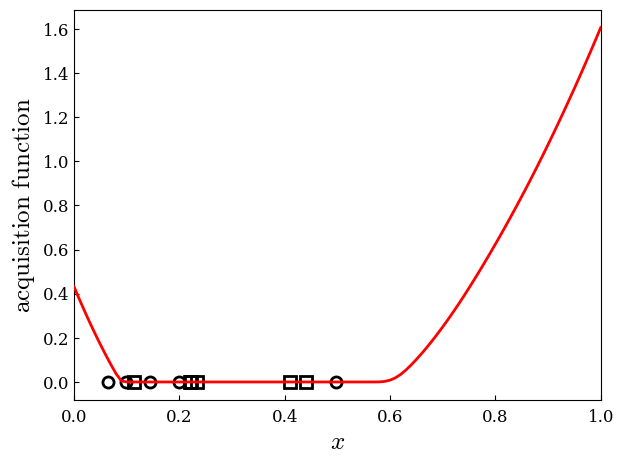

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [17]:
filenameinput1 = 'exampledata_sparse_1.txt'
# filenameoutput = 'acquisitionfunction_sparse_1.pdf'
fs = 12
fs_label = 18
fs_legend = 14
plt.rcParams['font.size'] = fs
data1 = pd.read_csv(filenameinput1,comment='#',delimiter='\s+',na_values='----').values
xsample = data1[:,0]
ysample1 = data1[:,1]-data1[:,1]
ysample2 = data1[:,2]-data1[:,2]
nSample = len(xsample)
xacqui = np.arange(0.0,1.0+1e-6,0.01)
yacqui = da_sparse_1.acquisitionFunction(xacqui.reshape(-1,1))
yacquiSD = yacqui[:,0]
yacquiEI = yacqui[:,1]
color0 = 'black'
color1 = 'red'
color2 = 'blue'
psample1, = plt.plot(xsample,ysample1, linewidth=0, linestyle='solid', color=color0, \
                     marker='s', markersize=8, markeredgewidth=2, markeredgecolor=color0, markerfacecolor='None', clip_on=False, zorder=3, \
                     label=r'$\mathrm{sample} \ (\mathrm{i})$')
psample2, = plt.plot(xsample,ysample2, linewidth=0, linestyle='solid', color=color0, \
                     marker='o', markersize=8, markeredgewidth=2, markeredgecolor=color0, markerfacecolor='None', clip_on=False, zorder=4, \
                     label=r'$\mathrm{sample} \ (\mathrm{ii})$')
pacquiEI, = plt.plot(xacqui,yacquiEI, linewidth=2, linestyle='solid', color=color1, \
                   marker='None', markersize=0, markeredgewidth=0, markeredgecolor=color1, markerfacecolor='None', clip_on=True, zorder=5, \
                   label=r'$\mathrm{acquisition} \ (\mathrm{function})$')
# pacquiSD, = plt.plot(xacqui,yacquiSD, linewidth=2, linestyle='solid', color=color2, \
#                    marker='None', markersize=0, markeredgewidth=0, markeredgecolor=color1, markerfacecolor='None', clip_on=True, zorder=5, \
#                    label=r'$\mathrm{acquisition} \ (\mathrm{function})$')
plt.xlabel(r'$x$', fontsize=fs_label)
plt.ylabel(r'$\mathrm{acquisition} \ \mathrm{function}$', fontsize=fs_label)
plt.xticks(np.arange(0.0,1.0+1e-6,0.2), y=-0.01)
# plt.yticks(np.arange(0.0,5.0+1e-6,1.0), x=-0.01)
plt.xlim(0.0,1.0)
# plt.ylim(-0.5,5.2)
plt.tight_layout()
# plt.savefig(filenameoutput, transparent=True)
plt.show()
## initialization.
plt.figure()

## Test 01.2: statistics.

In [26]:
def truemodel_sparse_2_target1(xt):
    return 2.0 - xt + 5.0*(xt-0.7)**2 + 20.0*(xt-0.5)**3
def truemodel_sparse_2_target2(xt):
    return truemodel_sparse_2_target1(xt) - 1.5

In [29]:
da_sparse_2 = claude.CLAUDE(nDescriptor=1, \
                            nTarget=2, \
                            degreePolynomialDescriptor = np.array([[0],[1],[2],[3]]), \
                            degreeActiveDescriptor = [[[0],[0,1]]])

print('read data for covariance matrix.')
datatable = pd.read_csv('exampledata_sparse_2.txt',comment='#',delimiter='\s+',na_values='----').values
xSample = datatable[:,0].reshape(-1,1)
ySample = datatable[:,(1,2)]
da_sparse_2.fit(xSample,ySample)

print('save model parameters.')
da_sparse_2.saveModelParameterToFile('parameter_model_sparse_2_output_1.xml')
print('save covariance matrix components.')
da_sparse_2.saveCovarianceMatrixToFile('covariance_matrix_sparse_2_output_1.xml')

read data for covariance matrix.
save model parameters.
save covariance matrix components.


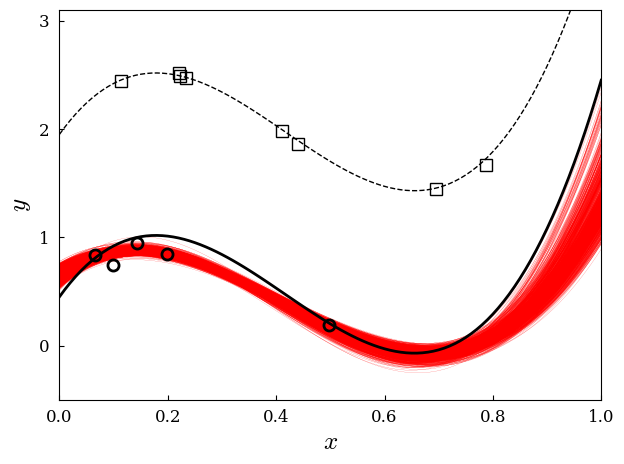

<Figure size 640x480 with 0 Axes>

In [30]:
filenameinput1 = 'exampledata_sparse_2.txt'
filenameModelParameter = 'parameter_model_sparse_2_output_1.xml'
filenameCovarianceMatrix = 'covariance_matrix_sparse_2_output_1.xml'
# filenameoutput = 'predictcurve_statistics_sparse_2.pdf'
fs = 12
fs_label = 18
fs_legend = 14
plt.rcParams['font.size'] = fs
rng = rnmanager.RandomNumberManager()
rng.restoreState()
color1 = 'red'
nStatistics = 1000
precisionMatrix = da_sparse_2.getPrecisionMatrixMax()
x1 = np.arange(0.0,1.0+1e-6,0.01)
y1 = np.zeros((x1.shape[0],2), dtype=float)
for iStatistics in range(nStatistics):
    da_sparse_2.transitionPrecisionMatrix(precisionMatrix)
    for i in range(x1.shape[0]):
        y1[i] = da_sparse_2.predict([x1[i]], precisionMatrix)
    p, = plt.plot(x1,y1[:,1], linewidth=0.1, linestyle='solid', color=color1, \
                marker='None', markersize=0, markeredgewidth=0, markeredgecolor=color1, markerfacecolor='None', clip_on=True, zorder=1, \
                label=r'$\mathrm{predict}$')
data1 = pd.read_csv(filenameinput1,comment='#',delimiter='\s+',na_values='----').values
xsample = data1[:,0]
ysample1 = data1[:,1]
ysample2 = data1[:,2]
xtrue = np.arange(0.0,1.0+1e-6,0.01)
ytrue1 = truemodel_sparse_target1(xtrue)
ytrue2 = truemodel_sparse_target2(xtrue)
color2 = 'black'
psample1, = plt.plot(xsample,ysample1, linewidth=0, linestyle='solid', color=color2, \
                     marker='s', markersize=8, markeredgewidth=1, markeredgecolor=color2, markerfacecolor='None', clip_on=True, zorder=4, \
                     label=r'$\mathrm{sample}$')
psample2, = plt.plot(xsample,ysample2, linewidth=0, linestyle='solid', color=color2, \
                     marker='o', markersize=8, markeredgewidth=2, markeredgecolor=color2, markerfacecolor='None', clip_on=True, zorder=4, \
                     label=r'$\mathrm{sample}$')
ptrue1, = plt.plot(xtrue,ytrue1, linewidth=1, linestyle='dashed', color=color2, \
                   marker='None', markersize=0, markeredgewidth=0, markeredgecolor=color2, markerfacecolor='None', clip_on=True, zorder=2, \
                   label=r'$\mathrm{true} \ \mathrm{model}$')
ptrue2, = plt.plot(xtrue,ytrue2, linewidth=2, linestyle='solid', color=color2, \
                   marker='None', markersize=0, markeredgewidth=0, markeredgecolor=color2, markerfacecolor='None', clip_on=True, zorder=2, \
                   label=r'$\mathrm{true} \ \mathrm{model}$')
# plt.legend([ptrue2,            psample2,            p], \
#            [ptrue2.get_label(),psample2.get_label(),p.get_label()], \
#            prop={'size':fs_legend}, numpoints=1, loc='upper left', ncol=1, framealpha=1.0)
plt.xlabel(r'$x$', fontsize=fs_label)
plt.ylabel(r'$y$', fontsize=fs_label)
plt.xticks(np.arange(0.0,1.0+1e-6,0.2), y=-0.01)
plt.yticks(np.arange(0.0,3.0+1e-6,1.0), x=-0.01)
plt.xlim(0.0,1.0)
plt.ylim(-0.5,3.1)
plt.tight_layout()
# plt.savefig(filenameoutput, transparent=True)
plt.show()
## initialization.
plt.figure()
rng.storeState()

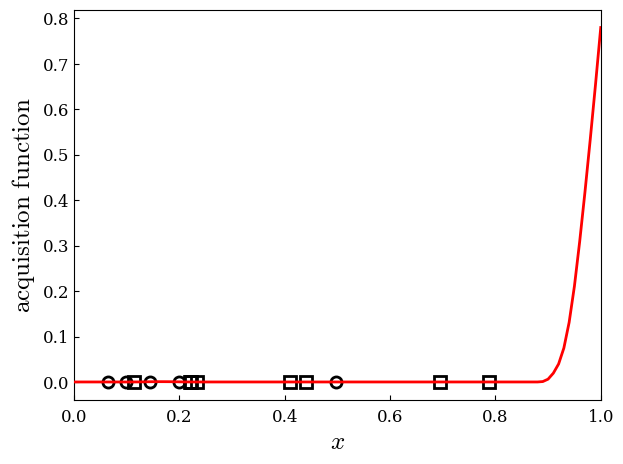

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [23]:
filenameinput1 = 'exampledata_sparse_2.txt'
# filenameoutput = 'acquisitionfunction_sparse_2.pdf'
fs = 12
fs_label = 18
fs_legend = 14
plt.rcParams['font.size'] = fs
data1 = pd.read_csv(filenameinput1,comment='#',delimiter='\s+',na_values='----').values
xsample = data1[:,0]
ysample1 = data1[:,1]-data1[:,1]
ysample2 = data1[:,2]-data1[:,2]
nSample = len(xsample)
xacqui = np.arange(0.0,1.0+1e-6,0.01)
yacqui = da_sparse_2.acquisitionFunction(xacqui.reshape(-1,1))
yacquiSD = yacqui[:,0]
yacquiEI = yacqui[:,1]
color0 = 'black'
color1 = 'red'
color2 = 'blue'
psample1, = plt.plot(xsample,ysample1, linewidth=0, linestyle='solid', color=color0, \
                     marker='s', markersize=8, markeredgewidth=2, markeredgecolor=color0, markerfacecolor='None', clip_on=False, zorder=3, \
                     label=r'$\mathrm{sample} \ (\mathrm{i})$')
psample2, = plt.plot(xsample,ysample2, linewidth=0, linestyle='solid', color=color0, \
                     marker='o', markersize=8, markeredgewidth=2, markeredgecolor=color0, markerfacecolor='None', clip_on=False, zorder=4, \
                     label=r'$\mathrm{sample} \ (\mathrm{ii})$')
pacquiEI, = plt.plot(xacqui,yacquiEI, linewidth=2, linestyle='solid', color=color1, \
                   marker='None', markersize=0, markeredgewidth=0, markeredgecolor=color1, markerfacecolor='None', clip_on=True, zorder=5, \
                   label=r'$\mathrm{acquisition} \ (\mathrm{function})$')
# pacquiSD, = plt.plot(xacqui,yacquiSD, linewidth=2, linestyle='solid', color=color2, \
#                    marker='None', markersize=0, markeredgewidth=0, markeredgecolor=color1, markerfacecolor='None', clip_on=True, zorder=5, \
#                    label=r'$\mathrm{acquisition} \ (\mathrm{function})$')
plt.xlabel(r'$x$', fontsize=fs_label)
plt.ylabel(r'$\mathrm{acquisition} \ \mathrm{function}$', fontsize=fs_label)
plt.xticks(np.arange(0.0,1.0+1e-6,0.2), y=-0.01)
# plt.yticks(np.arange(0.0,5.0+1e-6,1.0), x=-0.01)
plt.xlim(0.0,1.0)
# plt.ylim(-0.5,5.2)
plt.tight_layout()
# plt.savefig(filenameoutput, transparent=True)
plt.show()
## initialization.
plt.figure()

## Test 01.1&2: statistics.

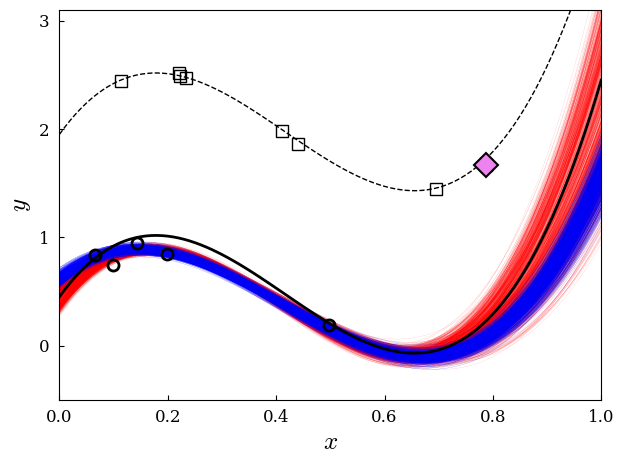

<Figure size 640x480 with 0 Axes>

In [43]:
filenameinput1 = 'exampledata_sparse_2.txt'
filenameoutput = 'predictcurve_statistics_sparse_1_2.pdf'
fs = 12
fs_label = 18
fs_legend = 14
plt.rcParams['font.size'] = fs
rng = rnmanager.RandomNumberManager()
rng.restoreState()
color11 = 'red'
color12 = 'blue'
nStatistics = 1000
### 1.
precisionMatrix = da_sparse.getPrecisionMatrixMax()
x1 = np.arange(0.0,1.0+1e-6,0.01)
y1 = np.zeros((x1.shape[0],2), dtype=float)
for iStatistics in range(nStatistics):
    da_sparse.transitionPrecisionMatrix(precisionMatrix)
    for i in range(x1.shape[0]):
        y1[i] = da_sparse.predict([x1[i]], precisionMatrix)
    p, = plt.plot(x1,y1[:,1], linewidth=0.05, linestyle='solid', color=color11, \
                marker='None', markersize=0, markeredgewidth=0, markeredgecolor=color11, markerfacecolor='None', clip_on=True, zorder=1, \
                label=r'$\mathrm{predict}$')
### 2.
precisionMatrix = da_sparse_2.getPrecisionMatrixMax()
x1 = np.arange(0.0,1.0+1e-6,0.01)
y1 = np.zeros((x1.shape[0],2), dtype=float)
for iStatistics in range(nStatistics):
    da_sparse_2.transitionPrecisionMatrix(precisionMatrix)
    for i in range(x1.shape[0]):
        y1[i] = da_sparse_2.predict([x1[i]], precisionMatrix)
    p, = plt.plot(x1,y1[:,1], linewidth=0.05, linestyle='solid', color=color12, \
                marker='None', markersize=0, markeredgewidth=0, markeredgecolor=color12, markerfacecolor='None', clip_on=True, zorder=1, \
                label=r'$\mathrm{predict}$')
data1 = pd.read_csv(filenameinput1,comment='#',delimiter='\s+',na_values='----').values
xsample = data1[:,0]
ysample1 = data1[:,1]
ysample2 = data1[:,2]
xtrue = np.arange(0.0,1.0+1e-6,0.01)
ytrue1 = truemodel_sparse_target1(xtrue)
ytrue2 = truemodel_sparse_target2(xtrue)
color2 = 'black'
color2a = 'violet'
psample1, = plt.plot(xsample,ysample1, linewidth=0, linestyle='solid', color=color2, \
                     marker='s', markersize=8, markeredgewidth=1, markeredgecolor=color2, markerfacecolor='None', clip_on=True, zorder=4, \
                     label=r'$\mathrm{sample}$')
psample1a, = plt.plot(xsample[6],ysample1[6], linewidth=0, linestyle='solid', color=color2a, \
                     marker='D', markersize=12, markeredgewidth=1.5, markeredgecolor=color2, markerfacecolor=color2a, clip_on=True, zorder=5, \
                     label=r'$\mathrm{sample}$')
psample2, = plt.plot(xsample,ysample2, linewidth=0, linestyle='solid', color=color2, \
                     marker='o', markersize=8, markeredgewidth=2, markeredgecolor=color2, markerfacecolor='None', clip_on=True, zorder=4, \
                     label=r'$\mathrm{sample}$')
ptrue1, = plt.plot(xtrue,ytrue1, linewidth=1, linestyle='dashed', color=color2, \
                   marker='None', markersize=0, markeredgewidth=0, markeredgecolor=color2, markerfacecolor='None', clip_on=True, zorder=2, \
                   label=r'$\mathrm{true} \ \mathrm{model}$')
ptrue2, = plt.plot(xtrue,ytrue2, linewidth=2, linestyle='solid', color=color2, \
                   marker='None', markersize=0, markeredgewidth=0, markeredgecolor=color2, markerfacecolor='None', clip_on=True, zorder=2, \
                   label=r'$\mathrm{true} \ \mathrm{model}$')
# plt.legend([ptrue2,            psample2,            p], \
#            [ptrue2.get_label(),psample2.get_label(),p.get_label()], \
#            prop={'size':fs_legend}, numpoints=1, loc='upper left', ncol=1, framealpha=1.0)
plt.xlabel(r'$x$', fontsize=fs_label)
plt.ylabel(r'$y$', fontsize=fs_label)
plt.xticks(np.arange(0.0,1.0+1e-6,0.2), y=-0.01)
plt.yticks(np.arange(0.0,3.0+1e-6,1.0), x=-0.01)
plt.xlim(0.0,1.0)
plt.ylim(-0.5,3.1)
plt.tight_layout()
# plt.savefig(filenameoutput, transparent=True)
plt.show()
## initialization.
plt.figure()
rng.storeState()

/Users/harashima/.pyenv/versions/3.11.9/envs/test_claude/lib/python3.11/site-packages/claude/CLAUDE.py:1215: RuntimeWarning: invalid value encountered in log
  * (-self.dimensionAvailablePattern[idx] * np.log(2*np.pi) + np.log(detPrecisionMatrixAvailable) - rtmp1)
/Users/harashima/.pyenv/versions/3.11.9/envs/test_claude/lib/python3.11/site-packages/claude/CLAUDE.py:1419: RuntimeWarning: overflow encountered in exp
  if (np.random.rand() < np.exp(dp)):


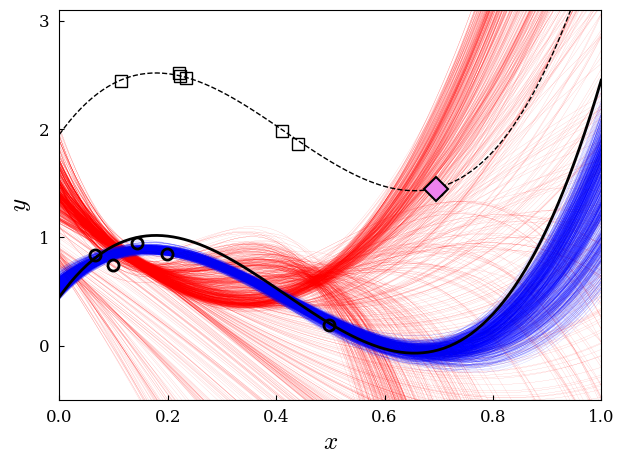

<Figure size 640x480 with 0 Axes>

In [18]:
filenameinput1 = 'exampledata_sparse.txt'
filenameoutput = 'predictcurve_statistics_sparse_1_3.pdf'
fs = 12
fs_label = 18
fs_legend = 14
plt.rcParams['font.size'] = fs
rng = rnmanager.RandomNumberManager()
rng.restoreState()
color11 = 'blue'
color12 = 'red'
nStatistics = 1000
### 0.
precisionMatrix = da_sparse.getPrecisionMatrixMax()
x1 = np.arange(0.0,1.0+1e-6,0.01)
y1 = np.zeros((x1.shape[0],2), dtype=float)
for iStatistics in range(nStatistics):
    da_sparse.transitionPrecisionMatrix(precisionMatrix)
    for i in range(x1.shape[0]):
        y1[i] = da_sparse.predict([x1[i]], precisionMatrix)
    p, = plt.plot(x1,y1[:,1], linewidth=0.05, linestyle='solid', color=color11, \
                marker='None', markersize=0, markeredgewidth=0, markeredgecolor=color11, markerfacecolor='None', clip_on=True, zorder=2, \
                label=r'$\mathrm{predict}$')
### 1.
precisionMatrix = da_sparse_1.getPrecisionMatrixMax()
x1 = np.arange(0.0,1.0+1e-6,0.01)
y1 = np.zeros((x1.shape[0],2), dtype=float)
for iStatistics in range(nStatistics):
    da_sparse_1.transitionPrecisionMatrix(precisionMatrix)
    for i in range(x1.shape[0]):
        y1[i] = da_sparse_1.predict([x1[i]], precisionMatrix)
    p, = plt.plot(x1,y1[:,1], linewidth=0.05, linestyle='solid', color=color12, \
                marker='None', markersize=0, markeredgewidth=0, markeredgecolor=color12, markerfacecolor='None', clip_on=True, zorder=1, \
                label=r'$\mathrm{predict}$')
data1 = pd.read_csv(filenameinput1,comment='#',delimiter='\s+',na_values='----').values
xsample = data1[:,0]
ysample1 = data1[:,1]
ysample2 = data1[:,2]
xtrue = np.arange(0.0,1.0+1e-6,0.01)
ytrue1 = truemodel_sparse_target1(xtrue)
ytrue2 = truemodel_sparse_target2(xtrue)
color2 = 'black'
color2a = 'violet'
psample1, = plt.plot(xsample,ysample1, linewidth=0, linestyle='solid', color=color2, \
                     marker='s', markersize=8, markeredgewidth=1, markeredgecolor=color2, markerfacecolor='None', clip_on=True, zorder=4, \
                     label=r'$\mathrm{sample}$')
psample1a, = plt.plot(xsample[0],ysample1[0], linewidth=0, linestyle='solid', color=color2a, \
                     marker='D', markersize=12, markeredgewidth=1.5, markeredgecolor=color2, markerfacecolor=color2a, clip_on=True, zorder=5, \
                     label=r'$\mathrm{sample}$')
psample2, = plt.plot(xsample,ysample2, linewidth=0, linestyle='solid', color=color2, \
                     marker='o', markersize=8, markeredgewidth=2, markeredgecolor=color2, markerfacecolor='None', clip_on=True, zorder=4, \
                     label=r'$\mathrm{sample}$')
ptrue1, = plt.plot(xtrue,ytrue1, linewidth=1, linestyle='dashed', color=color2, \
                   marker='None', markersize=0, markeredgewidth=0, markeredgecolor=color2, markerfacecolor='None', clip_on=True, zorder=2, \
                   label=r'$\mathrm{true} \ \mathrm{model}$')
ptrue2, = plt.plot(xtrue,ytrue2, linewidth=2, linestyle='solid', color=color2, \
                   marker='None', markersize=0, markeredgewidth=0, markeredgecolor=color2, markerfacecolor='None', clip_on=True, zorder=2, \
                   label=r'$\mathrm{true} \ \mathrm{model}$')
# plt.legend([ptrue2,            psample2,            p], \
#            [ptrue2.get_label(),psample2.get_label(),p.get_label()], \
#            prop={'size':fs_legend}, numpoints=1, loc='upper left', ncol=1, framealpha=1.0)
plt.xlabel(r'$x$', fontsize=fs_label)
plt.ylabel(r'$y$', fontsize=fs_label)
plt.xticks(np.arange(0.0,1.0+1e-6,0.2), y=-0.01)
plt.yticks(np.arange(0.0,3.0+1e-6,1.0), x=-0.01)
plt.xlim(0.0,1.0)
plt.ylim(-0.5,3.1)
plt.tight_layout()
# plt.savefig(filenameoutput, transparent=True)
plt.show()
## initialization.
plt.figure()
rng.storeState()

## Test 02: sine curve.

### true models.

In [39]:
def truemodel_sine_target1(xt):
    return 2.0 + 0.2*np.sin(2*np.pi*xt) + 0.3*np.sin(2*np.pi*2*xt) - 0.2*np.sin(2*np.pi*3*xt) + 0.1*np.sin(2*np.pi*4*xt) - 0.3*np.sin(2*np.pi*5*xt) + 0.2*np.sin(2*np.pi*6*xt)
def truemodel_sine_target2(xt):
    return truemodel_sine_target1(xt) - 2.0 - 0.6*np.sin(2*np.pi*xt)

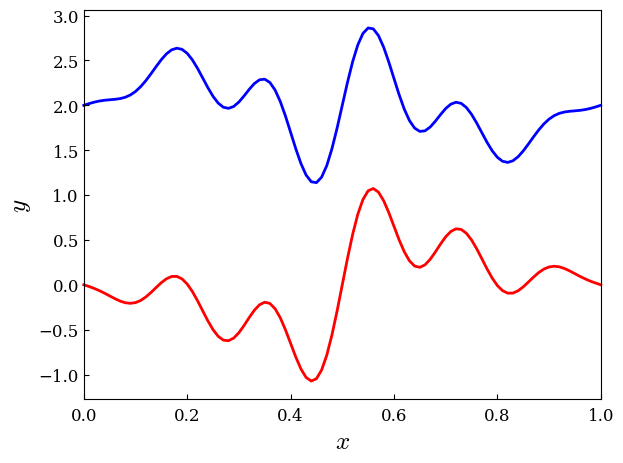

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [40]:
# filenameoutput = 'truecurve_sine.pdf'
fs = 12
fs_label = 18
fs_legend = 14
plt.rcParams['font.size'] = fs
xtrue1 = np.arange(0.0,1.0+1e-6,0.01)
xtrue2 = xtrue1
ytrue1 = truemodel_sine_target1(xtrue1)
ytrue2 = truemodel_sine_target2(xtrue2)
colorTrue1 = 'blue'
colorTrue2 = 'red'
ptrue1, = plt.plot(xtrue1,ytrue1, linewidth=2, linestyle='solid', color=colorTrue1, \
                   marker='None', markersize=0, markeredgewidth=0, markeredgecolor=colorTrue1, markerfacecolor='None', clip_on=False, zorder=1, \
                   label=r'$\mathrm{true} \ \mathrm{model} \ (\mathrm{i})$')
ptrue2, = plt.plot(xtrue2,ytrue2, linewidth=2, linestyle='solid', color=colorTrue2, \
                   marker='None', markersize=0, markeredgewidth=0, markeredgecolor=colorTrue2, markerfacecolor='None', clip_on=False, zorder=2, \
                   label=r'$\mathrm{true} \ \mathrm{model} \ (\mathrm{ii})$')
plt.xlabel(r'$x$', fontsize=fs_label)
plt.ylabel(r'$y$', fontsize=fs_label)
plt.xticks(np.arange(0.0,1.0+1e-6,0.2), y=-0.01)
# plt.yticks(np.arange(0.0,5.0+1e-6,1.0), x=-0.01)
plt.xlim(0.0,1.0)
# plt.ylim(-0.5,5.2)
plt.tight_layout()
plt.show()
# plt.savefig(filenameoutput, transparent=True)
## initialization.
plt.figure()

### Random sampling.

iSample = 0
iSample = 1
iSample = 2
iSample = 3
iSample = 4
iSample = 5


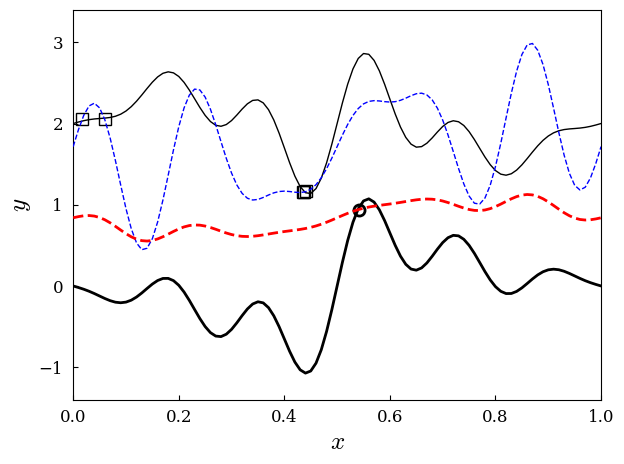

iSample = 6


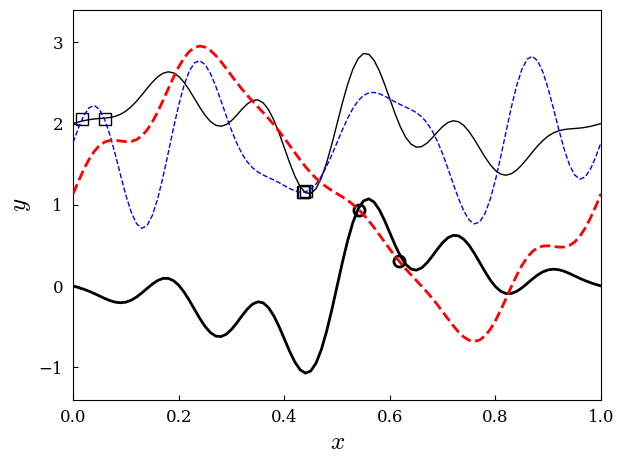

iSample = 7


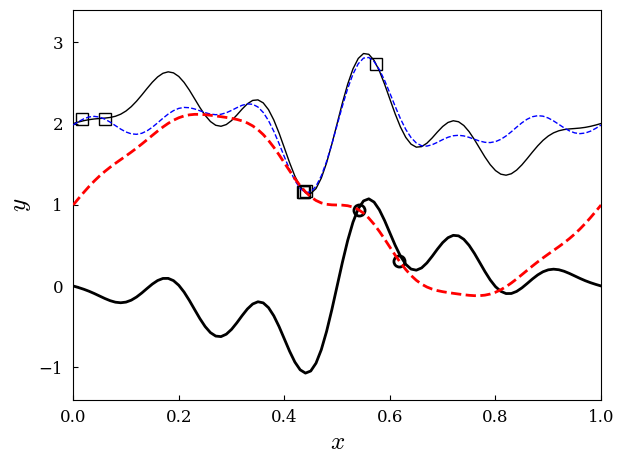

iSample = 8


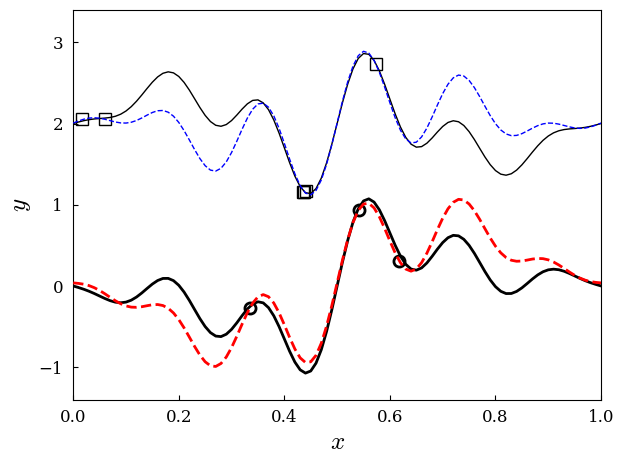

iSample = 9


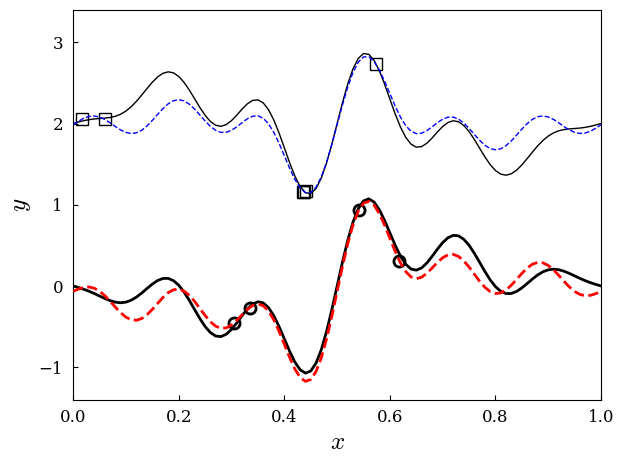

iSample = 10


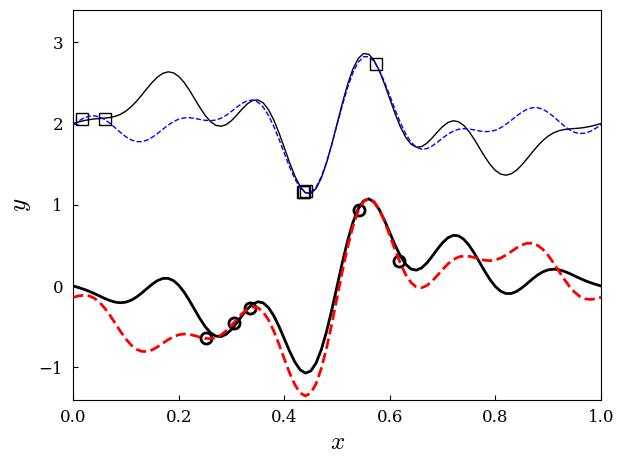

iSample = 11


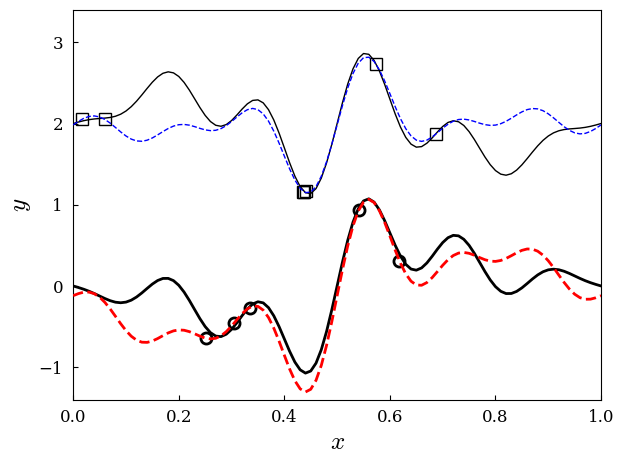

iSample = 12


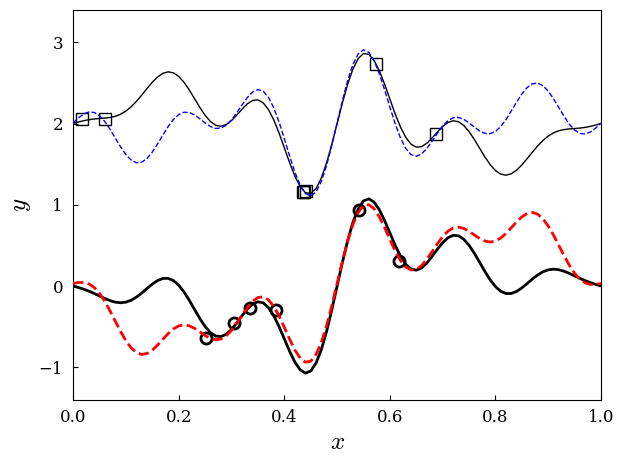

iSample = 13


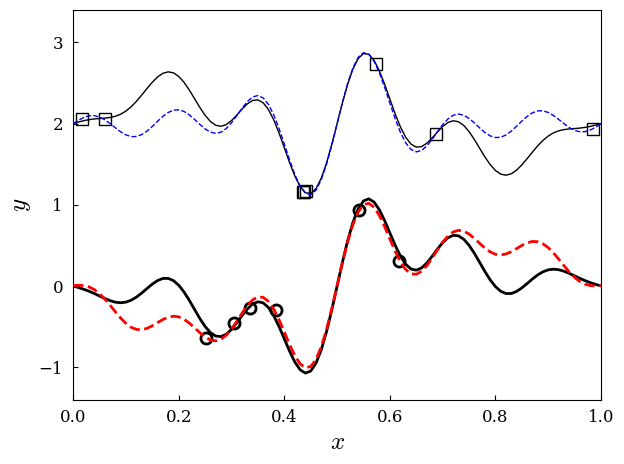

iSample = 14


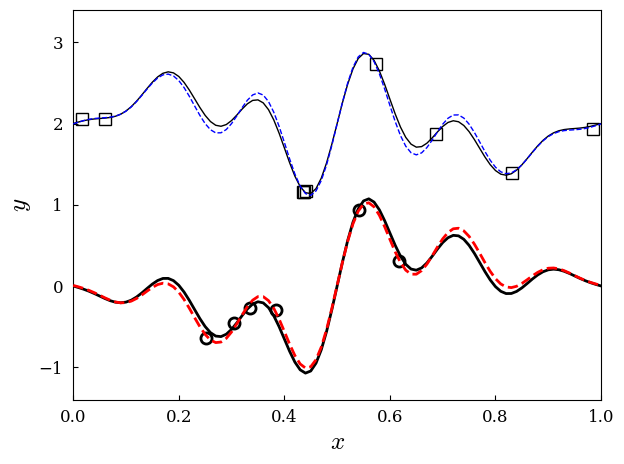

<Figure size 640x480 with 0 Axes>

In [41]:
nSampleMax = 15
filenameModelParameter = 'parameter_model_sine.xml'
filenameModelParameterOutput = 'parameter_model_sine_output.xml'
filenameCovarianceMatrix = 'covariance_matrix_sine.xml'
filenameCovarianceMatrixOutput = 'covariance_matrix_sine_output.xml'
fs = 12
fs_label = 18
fs_legend = 14
plt.rcParams['font.size'] = fs
color1 = 'blue'
color2 = 'red'
color3 = 'black'
rng = rnmanager.RandomNumberManager()
rng.restoreState()
xSample = []
xHilbertSample = []
ySample = []
xtrue = np.arange(0.0,1.0+1e-6,0.01)
ytrue1 = truemodel_sine_target1(xtrue)
ytrue2 = truemodel_sine_target2(xtrue)
da_sine = claude.CLAUDE(nDescriptor = 6, \
                        nTarget = 2, \
                        degreeActiveDescriptor = [[0,1], [1,1]])
# da_sine = claude.CLAUDE(nDescriptor = 6, \
#                         nTarget = 2, \
#                         degreeActiveDescriptor = [[[0,0,0,0,0,0],[0,1]], [[1,0,0,0,0,0],[0,1]]])
x1 = np.arange(0.0,1.0+1e-6,0.01)
y1 = np.zeros((x1.shape[0],2), dtype=float)
for iSample in range(0,nSampleMax):
    print('iSample = {0}'.format(iSample))
    # random sampling.
    xRand = np.random.rand()
    aRand = np.random.rand()
    if (aRand > 0.4):
        yRand1 = truemodel_sine_target1(xRand) + np.random.normal(0.0,0.03)
        yRand2 = np.nan
    else:
        yRand1 = np.nan
        yRand2 = truemodel_sine_target2(xRand) + np.random.normal(0.0,0.10)
    xSample.append(xRand)
    ySample.append([yRand1,yRand2])
    # transform x to xHilbert.
    xHilbert = [np.sin(2*np.pi*i*xRand) for i in range(1,7)]
    xHilbertSample.append(xHilbert)
    # initial data.
    if(iSample < 5):
        continue
    da_sine.fit(np.array(xHilbertSample),np.array(ySample))
    for i in range(x1.shape[0]):
        y1[i] = da_sine.predict([np.sin(2*np.pi*j*x1[i]) for j in range(1,7)])
    p1, = plt.plot(x1,y1[:,0], linewidth=1, linestyle='dashed', color=color1, \
                marker='None', markersize=0, markeredgewidth=0, markeredgecolor=color1, markerfacecolor='None', clip_on=True, zorder=5, \
                label=r'$\mathrm{predict}$')
    p2, = plt.plot(x1,y1[:,1], linewidth=2, linestyle='dashed', color=color2, \
                marker='None', markersize=0, markeredgewidth=0, markeredgecolor=color2, markerfacecolor='None', clip_on=True, zorder=5, \
                label=r'$\mathrm{predict}$')
    psample1, = plt.plot(xSample[:iSample+1],[ySample[i][0] for i in range(iSample+1)], linewidth=0, linestyle='solid', color=color3, \
                     marker='s', markersize=8, markeredgewidth=1, markeredgecolor=color3, markerfacecolor='None', clip_on=True, zorder=4, \
                     label=r'$\mathrm{sample}$')
    psample2, = plt.plot(xSample[:iSample+1],[ySample[i][1] for i in range(iSample+1)], linewidth=0, linestyle='solid', color=color3, \
                     marker='o', markersize=8, markeredgewidth=2, markeredgecolor=color3, markerfacecolor='None', clip_on=True, zorder=4, \
                     label=r'$\mathrm{sample}$')
    ptrue1, = plt.plot(xtrue,ytrue1, linewidth=1, linestyle='solid', color=color3, \
                   marker='None', markersize=0, markeredgewidth=0, markeredgecolor=color3, markerfacecolor='None', clip_on=True, zorder=2, \
                   label=r'$\mathrm{true} \ \mathrm{model}$')
    ptrue2, = plt.plot(xtrue,ytrue2, linewidth=2, linestyle='solid', color=color3, \
                   marker='None', markersize=0, markeredgewidth=0, markeredgecolor=color3, markerfacecolor='None', clip_on=True, zorder=2, \
                   label=r'$\mathrm{true} \ \mathrm{model}$')
    # plt.legend([ptrue2,            psample2,            p], \
    #            [ptrue2.get_label(),psample2.get_label(),p.get_label()], \
    #            prop={'size':fs_legend}, numpoints=1, loc='upper left', ncol=1, framealpha=1.0)
    plt.xlabel(r'$x$', fontsize=fs_label)
    plt.ylabel(r'$y$', fontsize=fs_label)
    plt.xticks(np.arange(0.0,1.0+1e-6,0.2), y=-0.01)
    plt.yticks(np.arange(-1.0,3.5+1e-6,1.0), x=-0.01)
    plt.xlim(0.0,1.0)
    plt.ylim(-1.4,3.4)
    plt.tight_layout()
    plt.show()
    ## initialization.
    plt.figure()
da_sine.saveModelParameterToFile(filenameModelParameterOutput)
da_sine.saveCovarianceMatrixToFile(filenameCovarianceMatrixOutput)
rng.storeState()

### Bayesian optimization.

iSample = 0
(xRand,yRand1,yRand2) =  0.968942098279056 1.972404169428208 nan
iSample = 1
(xRand,yRand1,yRand2) =  0.9700718296193457 nan 0.25321265306542373
iSample = 2
(xRand,yRand1,yRand2) =  0.7794048378542835 1.5712268892871535 nan
iSample = 3
(xRand,yRand1,yRand2) =  0.5482072807997806 2.873699248519289 nan
iSample = 4
(xRand,yRand1,yRand2) =  0.5547273192198701 2.865963754904151 nan
iSample = 5


/Users/harashima/.pyenv/versions/3.11.9/envs/test_claude/lib/python3.11/site-packages/claude/CLAUDE.py:1215: RuntimeWarning:

invalid value encountered in log



(xBO,yBO1,yBO2) =  0.75 nan 0.5268872569561928


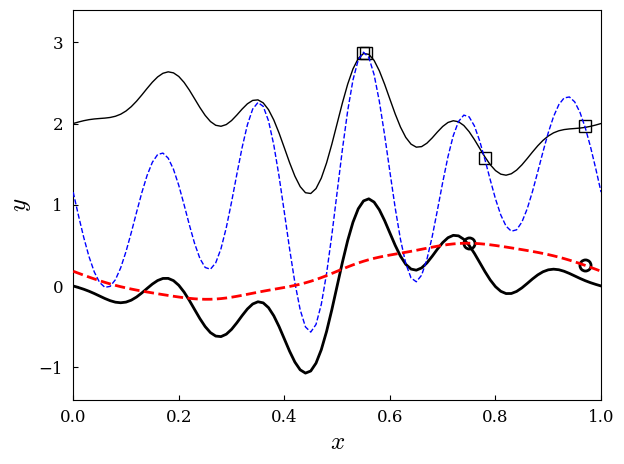

iSample = 6
(xBO,yBO1,yBO2) =  0.64 1.7205194041272742 nan


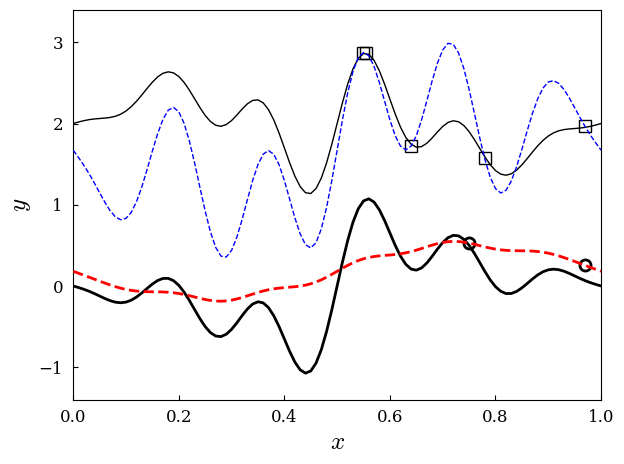

iSample = 7
(xBO,yBO1,yBO2) =  0.28 1.9564731147133165 nan


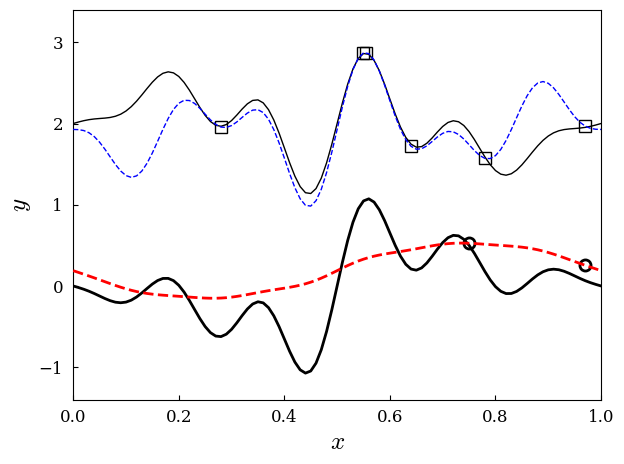

iSample = 8
(xBO,yBO1,yBO2) =  0.74 nan 0.5022942359726621


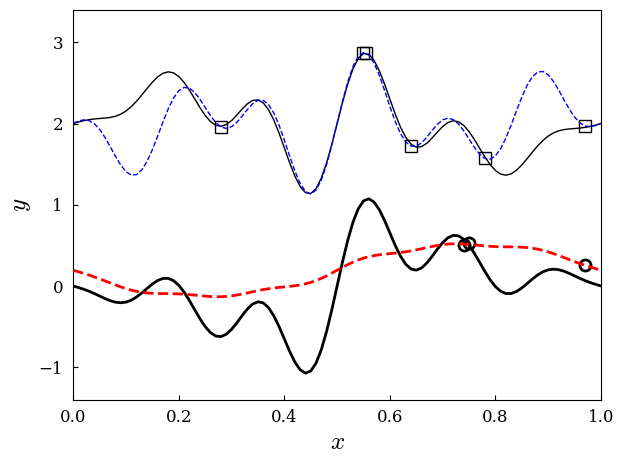

iSample = 9
(xBO,yBO1,yBO2) =  0.74 nan 0.45638122406157855


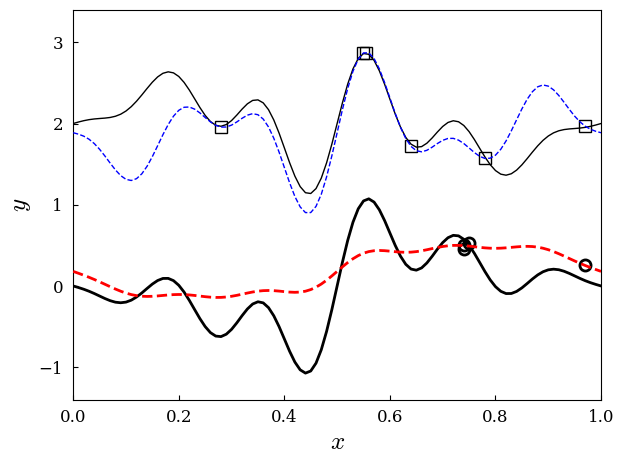

iSample = 10
(xBO,yBO1,yBO2) =  0.4 1.7274337088587441 nan


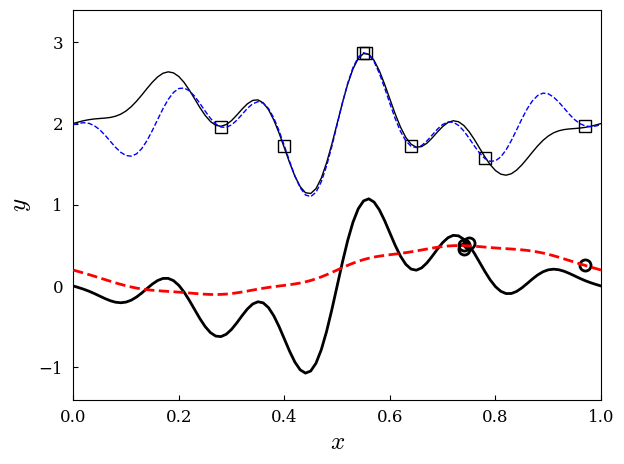

iSample = 11
(xBO,yBO1,yBO2) =  0.13 2.394638857082592 nan


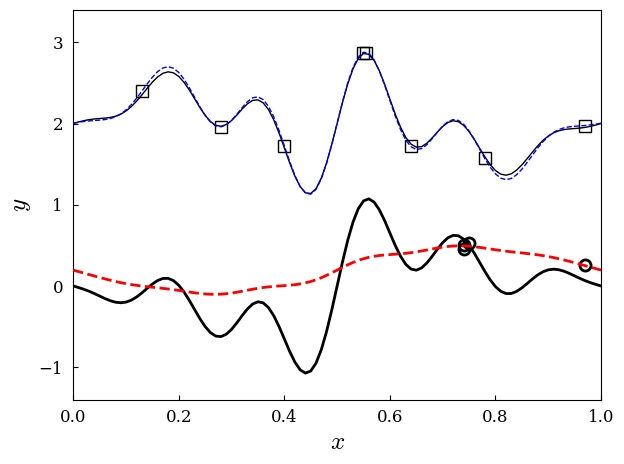

iSample = 12
(xBO,yBO1,yBO2) =  0.0 nan 0.08679529841228344


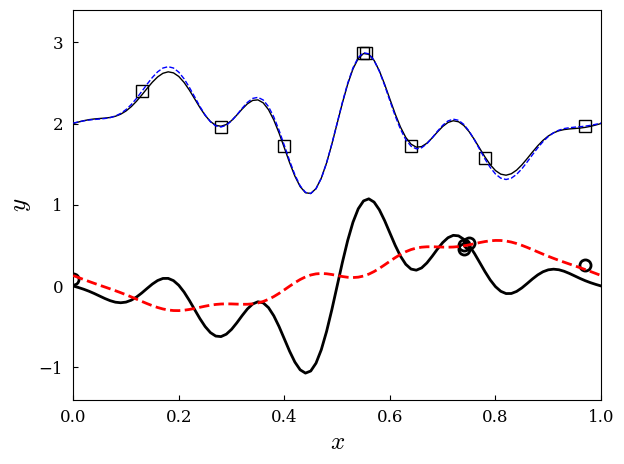

iSample = 13
(xBO,yBO1,yBO2) =  0.06 2.0511274758035594 nan


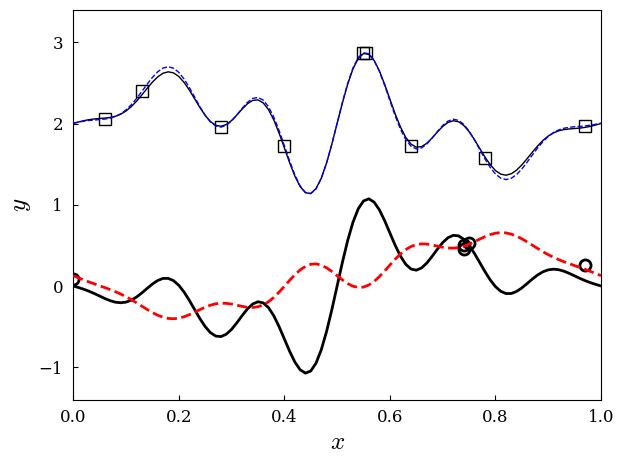

iSample = 14
(xBO,yBO1,yBO2) =  0.81 nan -0.20595653050574456


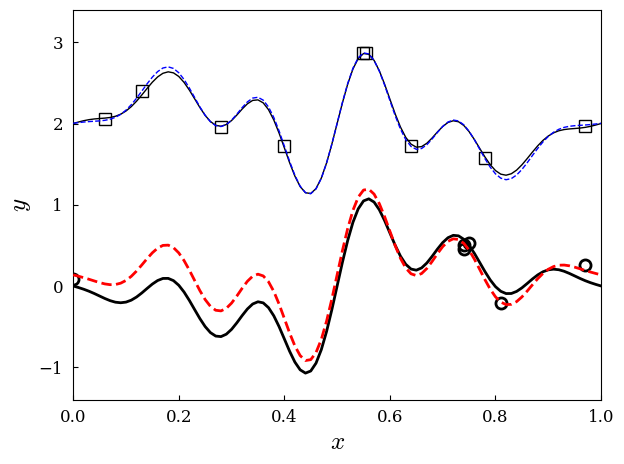

<Figure size 640x480 with 0 Axes>

In [42]:
nSampleMax = 15
filenameModelParameter = 'parameter_model_sine_bo.xml'
filenameModelParameterOutput = 'parameter_model_sine_bo_output.xml'
filenameCovarianceMatrix = 'covariance_matrix_sine_bo.xml'
filenameCovarianceMatrixOutput = 'covariance_matrix_sine_bo_output.xml'
fs = 12
fs_label = 18
fs_legend = 14
plt.rcParams['font.size'] = fs
color1 = 'blue'
color2 = 'red'
color3 = 'black'
rng = rnmanager.RandomNumberManager()
rng.restoreState()
xMesh = np.arange(0.0,1.0+1e-6,0.01)
xSample = []
xHilbertSample = []
ySample = []
xtrue = np.arange(0.0,1.0+1e-6,0.01)
ytrue1 = truemodel_sine_target1(xtrue)
ytrue2 = truemodel_sine_target2(xtrue)
da_sine_bo = claude.CLAUDE(nDescriptor = 6, \
                           nTarget = 2, \
                           degreeActiveDescriptor = [[[0,0,0,0,0,0],[0,1]], [[1,0,0,0,0,0],[0,1]]])
x1 = np.arange(0.0,1.0+1e-6,0.01)
y1 = np.zeros((x1.shape[0],2), dtype=float)
for iSample in range(0,nSampleMax):
    print('iSample = {0}'.format(iSample))
    if(iSample < 5):
        # random sampling.
        xRand = np.random.rand()
        aRand = np.random.rand()
        if (aRand > 0.4):
            yRand1 = truemodel_sine_target1(xRand) + np.random.normal(0.0,0.03)
            yRand2 = np.nan
        else:
            yRand1 = np.nan
            yRand2 = truemodel_sine_target2(xRand) + np.random.normal(0.0,0.10)
        xSample.append(xRand)
        ySample.append([yRand1,yRand2])
        # transform x to xHilbert.
        xHilbert = [np.sin(2*np.pi*i*xRand) for i in range(1,7)]
        xHilbertSample.append(xHilbert)
        da_sine_bo.updateCovarianceMatrix(xHilbert,[yRand1,yRand2])
        print('(xRand,yRand1,yRand2) = ',xRand,yRand1,yRand2)
        continue
    else:
        # Bayesian opt.
        ## Acquisition function.
        xHilbertList = np.array([[np.sin(2*np.pi*i*xMesh[idx]) for i in range(1,7)] for idx in range(xMesh.shape[0])])
        qeiList = da_sine_bo.acquisitionFunction(xHilbertList)
        ## first.
        aRand = np.random.rand()
        if (aRand > 0.4):
            iSampleMax = 0
            qeiMax = qeiList[0,0]
            for idx in range(1,qeiList.shape[0]):
                if (qeiMax < qeiList[idx,0]):
                    qeiMax = qeiList[idx,0]
                    iSampleMax = idx
            xBO = xMesh[iSampleMax]
            yBO1 = truemodel_sine_target1(xBO) + np.random.normal(0.0,0.03)
            yBO2 = np.nan
        else:
            ## second.
            iSampleMax = 0
            qeiMax = qeiList[0,1]
            for idx in range(1,qeiList.shape[0]):
                if (qeiMax < qeiList[idx,1]):
                    qeiMax = qeiList[idx,1]
                    iSampleMax = idx
            xBO = xMesh[iSampleMax]
            yBO1 = np.nan
            yBO2 = truemodel_sine_target2(xBO) + np.random.normal(0.0,0.10)
        xSample.append(xBO)
        ySample.append([yBO1,yBO2])
        xHilbert = [np.sin(2*np.pi*i*xBO) for i in range(1,7)]
        xHilbertSample.append(xHilbert)
        da_sine_bo.updateCovarianceMatrix(xHilbert,[yBO1,yBO2])
        print('(xBO,yBO1,yBO2) = ',xBO,yBO1,yBO2)
    da_sine_bo.resetPrecisionMatrixMax()
    da_sine_bo.findMaximumPosteriorProbability()
    for i in range(x1.shape[0]):
        y1[i] = da_sine_bo.predict([np.sin(2*np.pi*j*x1[i]) for j in range(1,7)])
    p1, = plt.plot(x1,y1[:,0], linewidth=1, linestyle='dashed', color=color1, \
                marker='None', markersize=0, markeredgewidth=0, markeredgecolor=color1, markerfacecolor='None', clip_on=True, zorder=5, \
                label=r'$\mathrm{predict}$')
    p2, = plt.plot(x1,y1[:,1], linewidth=2, linestyle='dashed', color=color2, \
                marker='None', markersize=0, markeredgewidth=0, markeredgecolor=color2, markerfacecolor='None', clip_on=True, zorder=5, \
                label=r'$\mathrm{predict}$')
    psample1, = plt.plot(xSample[:iSample+1],[ySample[i][0] for i in range(iSample+1)], linewidth=0, linestyle='solid', color=color3, \
                     marker='s', markersize=8, markeredgewidth=1, markeredgecolor=color3, markerfacecolor='None', clip_on=True, zorder=4, \
                     label=r'$\mathrm{sample}$')
    psample2, = plt.plot(xSample[:iSample+1],[ySample[i][1] for i in range(iSample+1)], linewidth=0, linestyle='solid', color=color3, \
                     marker='o', markersize=8, markeredgewidth=2, markeredgecolor=color3, markerfacecolor='None', clip_on=True, zorder=4, \
                     label=r'$\mathrm{sample}$')
    ptrue1, = plt.plot(xtrue,ytrue1, linewidth=1, linestyle='solid', color=color3, \
                   marker='None', markersize=0, markeredgewidth=0, markeredgecolor=color3, markerfacecolor='None', clip_on=True, zorder=2, \
                   label=r'$\mathrm{true} \ \mathrm{model}$')
    ptrue2, = plt.plot(xtrue,ytrue2, linewidth=2, linestyle='solid', color=color3, \
                   marker='None', markersize=0, markeredgewidth=0, markeredgecolor=color3, markerfacecolor='None', clip_on=True, zorder=2, \
                   label=r'$\mathrm{true} \ \mathrm{model}$')
    # plt.legend([ptrue2,            psample2,            p], \
    #            [ptrue2.get_label(),psample2.get_label(),p.get_label()], \
    #            prop={'size':fs_legend}, numpoints=1, loc='upper left', ncol=1, framealpha=1.0)
    plt.xlabel(r'$x$', fontsize=fs_label)
    plt.ylabel(r'$y$', fontsize=fs_label)
    plt.xticks(np.arange(0.0,1.0+1e-6,0.2), y=-0.01)
    plt.yticks(np.arange(-1.0,3.5+1e-6,1.0), x=-0.01)
    plt.xlim(0.0,1.0)
    plt.ylim(-1.4,3.4)
    plt.tight_layout()
    plt.show()
    ## initialization.
    plt.figure()
da_sine.saveModelParameterToFile(filenameModelParameterOutput)
da_sine.saveCovarianceMatrixToFile(filenameCovarianceMatrixOutput)
rng.storeState()

## Test 03: 2-dimensional system.

### Basis set.

In [10]:
def basis_sin(x):
    phi = [np.sin(2*np.pi*x[0]), \
           np.sin(2*np.pi*2*x[0]), \
           np.sin(2*np.pi*3*x[0]), \
           np.sin(2*np.pi*4*x[0]), \
           np.sin(2*np.pi*5*x[0]), \
           np.sin(2*np.pi*6*x[0]), \
           np.sin(2*np.pi*x[1]), \
           np.sin(2*np.pi*2*x[1]), \
           np.sin(2*np.pi*3*x[1]), \
           np.sin(2*np.pi*4*x[1]), \
           np.sin(2*np.pi*5*x[1]), \
           np.sin(2*np.pi*6*x[1])]
    return phi

### Definition: xMesh and xHilbertMesh.

In [11]:
nMesh1,nMesh2 = 31,31 # mesh grid size

# meshgrid range
x10,x11 = [0.0,1.0]
x20,x21 = [0.0,1.0]

# meshgrid step
dx1 = (x11-x10)/(nMesh1-1)
dx2 = (x21-x20)/(nMesh2-1)

# create all zeroes meshgrid
xMesh1 = np.zeros((nMesh1,nMesh2), dtype=float)
xMesh2 = np.zeros((nMesh1,nMesh2), dtype=float)


xHilbertMesh = []
mapMeshIdx = []
for i2 in range(nMesh2):
    for i1 in range(nMesh1):
        # fill meshgrid with values
        xMesh1[i1,i2] = i1*dx1 + x10
        xMesh2[i1,i2] = i2*dx2 + x20

        # calculate basis function for each [x,y]
        xHilbert = basis_sin([xMesh1[i1,i2],xMesh2[i1,i2]])
        xHilbertMesh.append(list(xHilbert))
        mapMeshIdx.append([i1,i2])
xHilbertMesh = np.array(xHilbertMesh)

### True model.

In [12]:
def truemodel_sine_2d_target1(xt):
    y = 4.0 \
        + 0.2*np.sin(2*np.pi*xt[0]) \
        + 0.3*np.sin(2*np.pi*2*xt[0]) \
        - 0.2*np.sin(2*np.pi*3*xt[0]) \
        + 0.1*np.sin(2*np.pi*4*xt[0]) \
        - 0.3*np.sin(2*np.pi*5*xt[0]) \
        + 0.2*np.sin(2*np.pi*6*xt[0]) \
        + 0.4*np.sin(2*np.pi*xt[1]) * np.sin(2*np.pi*xt[0]) \
        - 0.1*np.sin(2*np.pi*xt[1]) \
        + 0.4*np.sin(2*np.pi*2*xt[1]) \
        - 0.2*np.sin(2*np.pi*2*xt[1]) * np.sin(2*np.pi*xt[0]) \
        + 0.1*np.sin(2*np.pi*3*xt[1]) \
        - 0.1*np.sin(2*np.pi*4*xt[1]) \
        + 0.1*np.sin(2*np.pi*5*xt[1]) \
        - 0.3*np.sin(2*np.pi*5*xt[1]) * np.sin(2*np.pi*3*xt[0]) \
        - 0.2*np.sin(2*np.pi*6*xt[1])
    return y
def truemodel_sine_2d_target2(xt):
    y = truemodel_sine_2d_target1(xt) - 4.0 - 0.6*np.sin(2*np.pi*xt[0])
    return y


### Create surface

In [13]:
# filenameoutput = 'truemodel.svg'
xTrue1 = np.zeros((nMesh1,nMesh2), dtype=float)
xTrue2 = np.zeros((nMesh1,nMesh2), dtype=float)
yTrue1 = np.zeros((nMesh1,nMesh2), dtype=float)
yTrue2 = np.zeros((nMesh1,nMesh2), dtype=float)
for i2 in range(nMesh2):
    for i1 in range(nMesh1):
        xTrue1[i1,i2] = i1*dx1 + x10
        xTrue2[i1,i2] = i2*dx2 + x20
        yTrue1[i1,i2] = truemodel_sine_2d_target1([xTrue1[i1,i2],xTrue2[i1,i2]])
        yTrue2[i1,i2] = truemodel_sine_2d_target2([xTrue1[i1,i2],xTrue2[i1,i2]])
yMaxMesh1 = np.max(yTrue1)
yMaxMesh2 = np.max(yTrue2)
print('yMax1 on mesh = {0:14.8f}'.format(yMaxMesh1))
print('yMax2 on mesh = {0:14.8f}'.format(yMaxMesh2))
ptrue1 = go.Surface(x=xTrue1,y=xTrue2,z=yTrue1, colorscale=['rgb( 99, 110, 250)','rgb( 99, 110, 250)'], opacity=0.8, showscale=False, \
                    contours = {'x':{'show':True, 'start':0.0, 'end':1.0, 'size':1./30., 'color':'black'}, \
                                'y':{'show':True, 'start':0.0, 'end':1.0, 'size':1./30., 'color':'black'}})
ptrue2 = go.Surface(x=xTrue1,y=xTrue2,z=yTrue2, colorscale=['rgb(239, 101,  72)','rgb(239, 101,  72)'], opacity=0.8, showscale=False, \
                    contours = {'x':{'show':True, 'start':0.0, 'end':1.0, 'size':1./30., 'color':'black'}, \
                                'y':{'show':True, 'start':0.0, 'end':1.0, 'size':1./30., 'color':'black'}})
fig = go.Figure(data=[ptrue2, \
                      ptrue1])
phi = 0.65
fig.update_layout(width=700,height=700, scene=dict(xaxis_title='x1',yaxis_title='x2',zaxis_title='y'), \
                                scene_camera=dict(up=dict(x=0,y=0,z=1), \
                                center=dict(x=0,y=0,z=-0.23), \
                                eye=dict(x=-2.0*np.cos(2*np.pi*phi),y=-2.0*np.sin(2*np.pi*phi),z=1.1)))
# fig.write_image(filenameoutput)
fig.show()
## initialization.

yMax1 on mesh =     5.96847313
yMax2 on mesh =     2.21251512


### Initial data.

In [17]:
nSampleInitial1,nSampleInitial2 = 5,5
e1,e2 = 0.3,1.0

# Random manager, but for reproducibility, we use the same seed.
# rng = rnmanager.RandomNumberManager()
# rng.restoreState()

# randomly generate from [0,1] with shape of [10,2]
xInit = np.random.rand(nSampleInitial1+nSampleInitial2,2)
yInit = np.zeros((xInit.shape[0],2), dtype=float)

# y is truemodel from x with noise
for i in range(nSampleInitial1):
    yInit[i,0] = truemodel_sine_2d_target1(xInit[i]) + e1*(np.random.rand()-0.5)
    yInit[i,1] = np.nan
for i in range(nSampleInitial1,nSampleInitial1+nSampleInitial2):
    yInit[i,0] = np.nan
    yInit[i,1] = truemodel_sine_2d_target2(xInit[i]) + e2*(np.random.rand()-0.5)

# store for reproducibility

### Simple Bayesian optimization with ordinary least square.

In [19]:
nSampleTotal1 = 50
filenameModelParameterOLS = 'parameter_model_sine_2d_bo_ols.xml'
filenameCovarianceMatrixOLS = 'covariance_matrix_sine_2d_bo_ols.xml'

# initialize meshgrid, but with size of [31*31]
xPredOLS1 = np.zeros(nMesh1*nMesh2, dtype=float)
xPredOLS2 = np.zeros(nMesh1*nMesh2, dtype=float)
yPredOLS2 = np.zeros(nMesh1*nMesh2, dtype=float)

# fill meshgrid with values
idx = 0
for i2 in range(nMesh2):
    for i1 in range(nMesh1):
        xPredOLS1[idx] = i1*dx1 + x10
        xPredOLS2[idx] = i2*dx2 + x20
        idx += 1

"""
degPolyDes will represent
coef + x2^0(x1 + x1^2 + x1^3 + x1^4 + x1^5 + x1^6) + x2^1(x1 + x1^2 + x1^3 + x1^4 + x1^5 + x1^6) + ... + x2^6(x1 + x1^2 + x1^3 + x1^4 + x1^5 + x1^6)
or in short
(x1^0 + x1^1 + x1^2 + x1^3 + x1^4 + x1^5 + x1^6)(x2^0 + x2^1 + x2^2 + x2^3 + x2^4 + x2^5 + x2^6)
We choose this since we want to represent sum of below
w*np.sin(2*np.pi*n*x[:,0])*np.sin(2*np.pi*m*x[:,1])
"""
degPolyDes = []
for idx2 in range(7):
    deg2 = [0, 0, 0, 0, 0, 0]
    if (idx2 >= 1):
        deg2[idx2-1] = 1
    for idx1 in range(7):
        deg1 = [0, 0, 0, 0, 0, 0]
        if (idx1 >= 1):
            deg1[idx1-1] = 1
        degPolyDes.append(deg1 + deg2)

# activate const and x2 term (we know this is only the diff in true model)
# y = truemodel_sine_2d_target1(xt) - 4.0 - 0.6*np.sin(2*np.pi*xt[0])
da_sine_2d_bo_ols = claude.CLAUDE(nDescriptor = 12, \
                                  nTarget = 1, \
                                  degreePolynomialDescriptor = np.array(degPolyDes), \
                                  degreeActiveDescriptor = [[[0,0,0,0,0,0,0,0,0,0,0,0], [1]],
                                                            [[1,0,0,0,0,0,0,0,0,0,0,0], [1]]])

# TODO: check what this does
da_sine_2d_bo_ols.setNSampleMonteCarlo(10)

# we transform x to the sin function
xHilbert = np.zeros((nSampleInitial2, 12), dtype=float)
for iSample in range(xHilbert.shape[0]):
    xHilbert[iSample] = basis_sin(xInit[iSample+nSampleInitial1])

# we are doing nSampleInitial1: to get the last 5 samples (exp only)
da_sine_2d_bo_ols.fit(xHilbert,yInit[nSampleInitial1:,1].reshape(-1,1))
xSample1 = list(xInit[nSampleInitial1:,0])
xSample2 = list(xInit[nSampleInitial1:,1])
ySample2 = list(yInit[nSampleInitial1:,1])
qeiMaxList = []
yMaxList2 = []
for iIter in range(5,nSampleTotal1):
    print('iIter = {0}'.format(iIter))
    ## Acquisition function.                                                                                                        
    qeiMesh = da_sine_2d_bo_ols.acquisitionFunction(xHilbertMesh)
    # Calculate argmax of acquisition function.                                                                                     
    iSampleMax = np.argmax(qeiMesh)
    iMax1,iMax2 = mapMeshIdx[iSampleMax]

    # Add sample from max of acquisition function.
    xSample1.append(xMesh1[iMax1,iMax2])
    xSample2.append(xMesh2[iMax1,iMax2])
    ySample2.append(truemodel_sine_2d_target2([xMesh1[iMax1,iMax2],xMesh2[iMax1,iMax2]]) + e2*(np.random.rand())-0.5)

    # Update covariance matrix with new sample
    da_sine_2d_bo_ols.updateCovarianceMatrix(xHilbertMesh[iSampleMax],[ySample2[-1]])

    # Print out result, it's not necessary in the iteration, but it's good to know.
    print('   x_calc = {0:14.8f}, {1:14.8f}'.format(xMesh1[iMax1,iMax2],xMesh2[iMax1,iMax2]))
    print('   y_calc = {0:14.8f}'.format(ySample2[-1]))
    print('   acquisition function = {0:14.8f}'.format(qeiMesh[iSampleMax,0]))
    qeiMaxList.append(qeiMesh[iSampleMax,0])
    yMaxList2.append(truemodel_sine_2d_target2([xMesh1[iMax1,iMax2],xMesh2[iMax1,iMax2]]))
    
    # Redo da                                                                                                            
    da_sine_2d_bo_ols.resetPrecisionMatrixMax()
    da_sine_2d_bo_ols.findMaximumPosteriorProbability()

iIter = 5
   x_calc =     0.56666667,     0.56666667
   y_calc =     1.20905536
   acquisition function =     0.00239033
iIter = 6
   x_calc =     0.56666667,     0.56666667
   y_calc =     1.06316960
   acquisition function =     0.00298797
iIter = 7
   x_calc =     0.56666667,     0.53333333
   y_calc =     0.52771089
   acquisition function =     0.00204731
iIter = 8
   x_calc =     0.60000000,     0.56666667
   y_calc =     0.76785080
   acquisition function =     0.36361314
iIter = 9
   x_calc =     0.43333333,     0.43333333
   y_calc =    -0.65545286
   acquisition function =     0.64924065
iIter = 10
   x_calc =     0.60000000,     0.60000000
   y_calc =     1.21133735
   acquisition function =     0.03653010
iIter = 11
   x_calc =     0.60000000,     0.60000000
   y_calc =     1.38973519
   acquisition function =     0.00764325
iIter = 12
   x_calc =     0.00000000,     0.00000000
   y_calc =     0.37317234
   acquisition function =     0.00000000
iIter = 13
   x_calc =     0.

/Users/syahrizailm/Codes/lab/CLAUDE/venv/lib/python3.10/site-packages/claude/CLAUDE.py:1215: RuntimeWarning:

invalid value encountered in log



iIter = 24
   x_calc =     0.43333333,     0.06666667
   y_calc =    -1.29193465
   acquisition function =    41.66632146
iIter = 25
   x_calc =     0.76666667,     0.06666667
   y_calc =     0.57149024
   acquisition function =    56.45083090
iIter = 26
   x_calc =     0.70000000,     0.20000000
   y_calc =    -0.06309282
   acquisition function =    44.84591262
iIter = 27
   x_calc =     0.33333333,     0.23333333
   y_calc =     0.05445634
   acquisition function =    46.83984582
iIter = 28
   x_calc =     0.23333333,     0.70000000
   y_calc =    -0.03218316
   acquisition function =    41.26143004
iIter = 29
   x_calc =     0.63333333,     0.16666667
   y_calc =    -0.10178940
   acquisition function =    42.84780443
iIter = 30
   x_calc =     0.13333333,     0.46666667
   y_calc =     0.44129138
   acquisition function =    48.45902907
iIter = 31
   x_calc =     0.80000000,     0.86666667
   y_calc =    -0.66905585
   acquisition function =    37.23062176
iIter = 32
   x_calc =  

### Show change in yMaxList

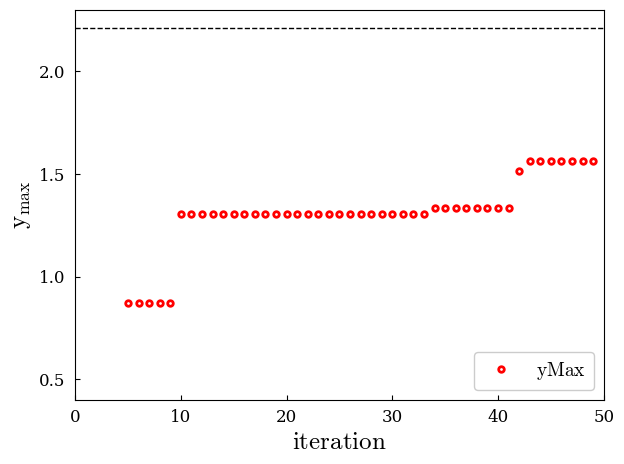

Done.


<Figure size 640x480 with 0 Axes>

In [20]:
fs = 12
fs_label = 18
fs_legend = 14
plt.rcParams['font.size'] = fs
color1 = 'red'
ytmp = np.array(yMaxList2)
for i in range(1,ytmp.shape[0]):
    ytmp[i] = max(ytmp[i-1],ytmp[i])
pyMax, = plt.plot(range(5,5+len(ytmp)),ytmp, linewidth=0, linestyle='None', color=color1, \
            marker='o', markersize=4, markeredgewidth=2, markeredgecolor=color1, markerfacecolor='None', clip_on=True, zorder=5, \
            label=r'$\mathrm{yMax}$')
plt.legend([pyMax], [pyMax.get_label()], \
            prop={'size':fs_legend}, numpoints=1, loc='lower right', ncol=1, framealpha=1.0)
plt.xlabel(r'$\mathrm{iteration}$', fontsize=fs_label)
plt.ylabel(r'$\mathrm{y}_{\mathrm{max}}$', fontsize=fs_label)
plt.xlim(0.0,50.0)
plt.xticks(np.arange(0.0,50.0+1e-6,10.0), y=-0.01)
plt.ylim(0.4,2.3)
plt.yticks(np.arange(0.5,2.3+1e-6,0.5), x=-0.01)
plt.hlines(yMaxMesh2,plt.xlim()[0],plt.xlim()[1], color='black', linestyle='dashed', lw=1.0)
plt.tight_layout()
plt.show()
## initialization.
plt.figure()
print("Done.")

### Bayesian optimization with data assimilation.

In [21]:
nSampleTotal1 = 20 # only 20?
nSamplePerIter1 = 3

filenameModelParameterCalc3 = 'parameter_model_sine_2d_bo_calc3.xml'
filenameCovarianceMatrixCalc3 = 'covariance_matrix_sine_2d_bo_calc3.xml'
xPredCalc31 = np.zeros(nMesh1*nMesh2, dtype=float)
xPredCalc32 = np.zeros(nMesh1*nMesh2, dtype=float)
yPredCalc32 = np.zeros(nMesh1*nMesh2, dtype=float)
idx = 0

for i2 in range(nMesh2):
    for i1 in range(nMesh1):
        xPredCalc31[idx] = i1*dx1 + x10
        xPredCalc32[idx] = i2*dx2 + x20
        idx += 1
degPolyDes = []
for idx2 in range(7):
    deg2 = [0, 0, 0, 0, 0, 0]
    if (idx2 >= 1):
        deg2[idx2-1] = 1
    for idx1 in range(7):
        deg1 = [0, 0, 0, 0, 0, 0]
        if (idx1 >= 1):
            deg1[idx1-1] = 1
        degPolyDes.append(deg1 + deg2)
da_sine_2d_bo_calc3 = claude.CLAUDE(nDescriptor = 12, \
                                    nTarget = 2, \
                                    degreePolynomialDescriptor = np.array(degPolyDes), \
                                    degreeActiveDescriptor = [[0, 1], \
                                                              [1, 1]])
# da_sine_2d_bo_calc3 = claude.CLAUDE(nDescriptor = 12, \
#                                     nTarget = 2, \
#                                     degreePolynomialDescriptor = np.array(degPolyDes), \
#                                     degreeActiveDescriptor = [[[0,0,0,0,0,0,0,0,0,0,0,0], [0,1]], \
#                                                               [[1,0,0,0,0,0,0,0,0,0,0,0], [0,1]]])
da_sine_2d_bo_calc3.setNSampleMonteCarlo(10)
## fit initial data.

# Now we are using all the initial data
xHilbert = np.zeros((nSampleInitial1 + nSampleInitial2, 12), dtype=float)
for iSample in range(xHilbert.shape[0]):
    xHilbert[iSample] = basis_sin(xInit[iSample])

da_sine_2d_bo_calc3.fit(xHilbert,yInit)

# Both exp and comp
xSample1 = list(xInit[:,0])
xSample2 = list(xInit[:,1])

ySample1 = list(yInit[:,0])
ySample2 = list(yInit[:,1])

qeiMaxList = []
yMaxList2 = []

# We are doing iter from 5 to 20
for iIter in range(5,nSampleTotal1):
    print('iIter = {0}'.format(iIter))
    # Sampling for model 1.
    print('   model 1')
    qeiMaxTmp = []
    yMaxTmp = []

    # We make 3 model
    for iIter1 in range(nSamplePerIter1):
        print('      iIter = {0}-{1}'.format(iIter, iIter1))
        ## Acquisition function. 
        # Not that for each iter, we only update cov matrix to count acq function
        qeiMesh = da_sine_2d_bo_calc3.acquisitionFunction(xHilbertMesh)

        # Calculate argmax of acquisition function.
        iSampleMax = np.argmax(qeiMesh[:,0])
        iMax1,iMax2 = mapMeshIdx[iSampleMax]

        # Add sample from max of acquisition function.
        xSample1.append(xMesh1[iMax1,iMax2])
        xSample2.append(xMesh2[iMax1,iMax2])
        ySample1.append(truemodel_sine_2d_target1([xMesh1[iMax1,iMax2],xMesh2[iMax1,iMax2]]) + e1*(np.random.rand())-0.5)
        ySample2.append(np.nan)

        # Update covariance matrix with new sample
        da_sine_2d_bo_calc3.updateCovarianceMatrix(xHilbertMesh[iSampleMax],[ySample1[-1],np.nan])
        print('      x_calc = {0:14.8f}, {1:14.8f}'.format(xMesh1[iMax1,iMax2],xMesh2[iMax1,iMax2]))
        print('      y_calc = {0:14.8f}, {1}'.format(ySample1[-1],np.nan))
        print('      acquisition function = {0:14.8f}, {1:14.8f}'.format(qeiMesh[iSampleMax,0],qeiMesh[iSampleMax,1]))
        qeiMaxTmp.append(qeiMesh[iSampleMax])
        yMaxTmp.append([truemodel_sine_2d_target1([xMesh1[iMax1,iMax2],xMesh2[iMax1,iMax2]]), \
                        truemodel_sine_2d_target2([xMesh1[iMax1,iMax2],xMesh2[iMax1,iMax2]])])
    
    # Sampling for model 2.
    print('   model 2')
    ## Acquisition function.
    qeiMesh = da_sine_2d_bo_calc3.acquisitionFunction(xHilbertMesh)
    # Calculate argmax of acquisition function.
    iSampleMax = np.argmax(qeiMesh[:,1])
    iMax1,iMax2 = mapMeshIdx[iSampleMax]
    xSample1.append(xMesh1[iMax1,iMax2])
    xSample2.append(xMesh2[iMax1,iMax2])
    ySample1.append(np.nan)
    ySample2.append(truemodel_sine_2d_target2([xMesh1[iMax1,iMax2],xMesh2[iMax1,iMax2]]) + e2*(np.random.rand())-0.5)
    da_sine_2d_bo_calc3.updateCovarianceMatrix(xHilbertMesh[iSampleMax],[np.nan,ySample2[-1]])
    print('      x_calc = {0:14.8f}, {1:14.8f}'.format(xMesh1[iMax1,iMax2],xMesh2[iMax1,iMax2]))
    print('      y_calc = {0}, {1:14.8f}'.format(np.nan,ySample2[-1]))
    print('      acquisition function = {0:14.8f}, {1:14.8f}'.format(qeiMesh[iSampleMax,0],qeiMesh[iSampleMax,1]))
    qeiMaxTmp.append(qeiMesh[iSampleMax])
    yMaxTmp.append([truemodel_sine_2d_target1([xMesh1[iMax1,iMax2],xMesh2[iMax1,iMax2]]), \
                    truemodel_sine_2d_target2([xMesh1[iMax1,iMax2],xMesh2[iMax1,iMax2]])])
    qeiMaxList.append(copy.deepcopy(np.array(qeiMaxTmp).reshape(-1)))
    yMaxList2.append(copy.deepcopy(np.array(yMaxTmp).reshape(-1)))
    # Start regression.
    da_sine_2d_bo_calc3.resetPrecisionMatrixMax()
    da_sine_2d_bo_calc3.findMaximumPosteriorProbability()

Warning in findMaximumPosteriorProbability: maximization for posterior probability is not converged.
iIter = 5
   model 1
      iIter = 5-0
      x_calc =     0.76666667,     0.06666667
      y_calc =     3.26498399, nan
      acquisition function =     0.16770998,     0.08555972
      iIter = 5-1
      x_calc =     0.76666667,     0.06666667
      y_calc =     3.29205431, nan
      acquisition function =     0.25455402,     0.26889223
      iIter = 5-2
      x_calc =     0.76666667,     0.06666667
      y_calc =     3.29628291, nan
      acquisition function =     0.26266072,     0.28815819
   model 2
      x_calc =     0.70000000,     0.26666667
      y_calc = nan,    -0.60074660
      acquisition function =     0.02730332,     0.88120349
Warning in findMaximumPosteriorProbability: maximization for posterior probability is not converged.
iIter = 6
   model 1
      iIter = 6-0
      x_calc =     0.33333333,     0.63333333
      y_calc =     4.31690639, nan
      acquisition function =

/Users/syahrizailm/Codes/lab/CLAUDE/venv/lib/python3.10/site-packages/claude/CLAUDE.py:1578: RuntimeWarning:

invalid value encountered in sqrt



      x_calc =     0.00000000,     0.00000000
      y_calc =     3.66666384, nan
      acquisition function =            nan,     0.00000000
      iIter = 6-2
      x_calc =     0.00000000,     0.00000000
      y_calc =     3.69934963, nan
      acquisition function =            nan,     0.00000000
   model 2
      x_calc =     0.00000000,     0.00000000
      y_calc = nan,     0.28629058
      acquisition function =     0.00000000,     0.00000000
Warning in findMaximumPosteriorProbability: maximization for posterior probability is not converged.
iIter = 7
   model 1
      iIter = 7-0
      x_calc =     1.00000000,     0.50000000
      y_calc =     3.72092796, nan
      acquisition function =            nan,     0.00000000
      iIter = 7-1
      x_calc =     0.93333333,     0.93333333
      y_calc =     3.18112493, nan
      acquisition function =     5.21002817,     0.00000000
      iIter = 7-2
      x_calc =     0.93333333,     0.80000000
      y_calc =     3.75836408, nan
      acq

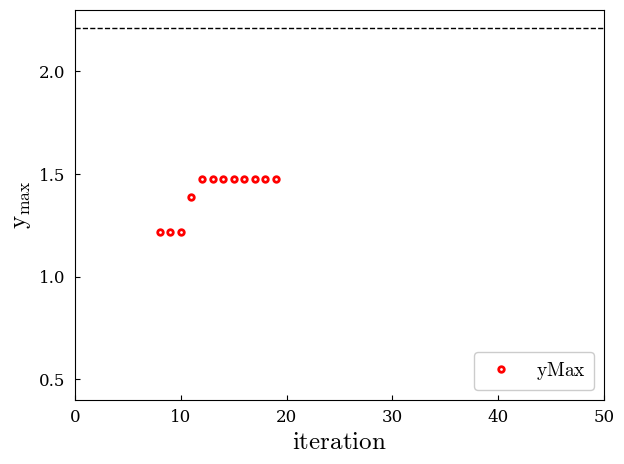

Done.


<Figure size 640x480 with 0 Axes>

In [22]:
fs = 12
fs_label = 18
fs_legend = 14
plt.rcParams['font.size'] = fs
color1 = 'red'
ytmp = np.array([yMaxList2[i][-1] for i in range(len(yMaxList2))])
for i in range(1,ytmp.shape[0]):
    ytmp[i] = max(ytmp[i-1],ytmp[i])
pyMax, = plt.plot(range(5,5+len(ytmp)),ytmp, linewidth=0, linestyle='None', color=color1, \
            marker='o', markersize=4, markeredgewidth=2, markeredgecolor=color1, markerfacecolor='None', clip_on=True, zorder=5, \
            label=r'$\mathrm{yMax}$')
plt.legend([pyMax], [pyMax.get_label()], \
            prop={'size':fs_legend}, numpoints=1, loc='lower right', ncol=1, framealpha=1.0)
plt.xlabel(r'$\mathrm{iteration}$', fontsize=fs_label)
plt.ylabel(r'$\mathrm{y}_{\mathrm{max}}$', fontsize=fs_label)
plt.xlim(0.0,50.0)
plt.xticks(np.arange(0.0,50.0+1e-6,10.0), y=-0.01)
plt.ylim(0.4,2.3)
plt.yticks(np.arange(0.5,2.3+1e-6,0.5), x=-0.01)
plt.hlines(yMaxMesh2,plt.xlim()[0],plt.xlim()[1], color='black', linestyle='dashed', lw=1.0)
plt.tight_layout()
plt.show()
## initialization.
plt.figure()
print("Done.")